# Résiliation client SaaS (churn) — Notebook de certification

| | |
|---|---|
| **Certification** | « Concevoir et implémenter une solution d'intelligence artificielle » — référentiel C1 → C9 |
| **Cas d'usage** | 01 — Résiliation client SaaS (churn) : classification binaire + régression de la valeur vie client |
| **Candidat** | Guillaume Saidani |
| **Date** | 23 septembre 2026 (date d'exécution affichée par la cellule ci-dessous) |
| **Version** | v2 — Gold dataset v2, modèles v2 (la v1 reste consultable dans `notebooks/00` à `06`) |
| **Code source** | https://github.com/guillaumesaidani-coder/churn_saas |
| **Jeu de données et modèles (téléchargement libre)** | https://github.com/guillaumesaidani-coder/churn_saas/releases/tag/v2.0 |
| **Versioning DVC** (compte DagsHub gratuit requis pour naviguer) | https://dagshub.com/guillaume.saidani/churn_saas |
| **Suivi des entraînements (MLflow)** | https://dagshub.com/guillaume.saidani/churn_saas.mlflow |

## Comment lire ce notebook

Ce notebook suit **le plan imposé par le règlement de l'épreuve** (§0 à §15). Il se lit seul,
sans explication orale : chaque résultat affiché est produit par le code qui le précède.

Quatre types de blocs reviennent tout au long du document :

| Bloc | Rôle |
|---|---|
| 📘 **Explication** | Commentaire pédagogique placé **avant chaque cellule de code** : ce qu'elle fait, pourquoi, et ce qu'il faut en retenir. Ces cellules portent le tag `pedagogie` : elles pourront être retirées automatiquement pour une version plus courte. |
| 📓 **Journal de bord** | Synthèse des constats et des décisions à la fin de chaque grande étape, comme l'exige le règlement. |
| ⚖️ **Décisions D1 à D15** | Choix de cadrage argumentés (atelier de cadrage n°1 : D1–D7 ; point de contact métier n°3 : D8–D15). Exercice mené seul : ce sont des choix justifiés par le candidat, pas des validations d'un commanditaire réel. |
| ⚠️ **Hypothèses H01 à H05** | Paramètres non vérifiables dans les données, toujours étiquetés comme tels et testés en sensibilité. |

**Règle méthodologique centrale.** Le jeu de test (20 % des comptes) est mis de côté dès la
préparation et **n'est utilisé qu'une seule fois**, en §9, pour mesurer la performance du
modèle final. Tous les choix (variables, modèle, hyperparamètres, seuil de décision) sont faits
en validation croisée sur le seul jeu d'entraînement.

📘 **Explication — cellule d'environnement**

Cette première cellule prépare tout ce dont le notebook a besoin :

- **Imports** : `pandas`/`numpy` pour les tableaux, `matplotlib` pour les graphiques, `sklearn`
  pour les modèles, `joblib` pour sauvegarder les modèles sur disque.
- **Chemins** : le notebook peut être lancé depuis `notebooks/` (cas normal, et cas du pipeline
  DVC) ou depuis la racine du projet ; `ROOT` pointe toujours vers la racine. On ajoute `ROOT` au
  `sys.path` pour pouvoir importer le code réutilisable du dossier `src/`.
- **Constantes métier** : elles traduisent les décisions de cadrage en paramètres (rappel cible
  de 80 % = D9, capacité de 150 comptes par mois = D10, etc.). Les regrouper ici évite des
  « nombres magiques » dispersés dans le code.
- **`RANDOM_STATE = 42`** : graine aléatoire fixe. Toute opération aléatoire (découpage des
  données, forêts aléatoires) donnera exactement le même résultat à chaque exécution : c'est la
  condition de la **reproductibilité**.
- **`sauver_figure`** : petite fonction utilitaire qui enregistre chaque graphique dans
  `data/model_v2/figures/`. Ces fichiers sont des **artefacts** livrés avec le notebook.

À retenir : un notebook reproductible commence par un environnement explicite (versions,
chemins, graines). La cellule affiche les versions des bibliothèques pour que n'importe qui
puisse recréer le même environnement (voir aussi `requirements-dev.txt`, §15).

In [1]:
import json
import os
import platform
import subprocess
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn

# Racine du projet, que le notebook soit lancé depuis notebooks/ ou depuis la racine
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))                       # rend le dossier src/ importable
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
warnings.filterwarnings("ignore", category=FutureWarning)

# Emplacements des données et des artefacts
RAW_DIR = ROOT / "Examen_cas d'usage candidat"      # fichiers fournis par l'énoncé (versionnés par DVC)
GOLD_DIR = ROOT / "data" / "gold"                   # Gold v1 (notebook 03) et Gold v2 (ce notebook)
MODEL_V1_DIR = ROOT / "data" / "model"              # modèles v1 (notebooks 04-06), pour comparaison
MODEL_DIR = ROOT / "data" / "model_v2"              # artefacts produits par ce notebook
FIG_DIR = MODEL_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Constantes issues du cadrage (décisions D8-D10, faits F14, hypothèses H01)
RANDOM_STATE = 42          # graine unique : reproductibilité
RAPPEL_CIBLE_D9 = 0.80     # D9 : le seuil doit garantir un rappel >= 80 %
CAPACITE_CSM_D10 = 150     # D10 : comptes traitables par les CSM à chaque cycle mensuel
GAIN_MIN_D8 = 0.15         # D8 : le modèle doit battre la baseline métier de +0,15 de PR-AUC
COUT_FN_EUR = 6879         # F14 : valeur vie client médiane des comptes qui résilient
COUTS_FP_EUR = [50, 150]   # H01 : coût d'une relance CS (fourchette, hypothèse)
PSI_SEUIL_ALERTE = 0.25    # seuil d'alerte de dérive, identique à drift_alert_rules.yml

LIENS = {
    "GitHub": "https://github.com/guillaumesaidani-coder/churn_saas",
    "DagsHub (données DVC)": "https://dagshub.com/guillaume.saidani/churn_saas",
    "MLflow": "https://dagshub.com/guillaume.saidani/churn_saas.mlflow",
}

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
COULEURS = {"non_churn": "#4C78A8", "churn": "#E45756", "neutre": "#9D9D9D"}


def sauver_figure(fig, nom: str) -> Path:
    """Enregistre une figure dans data/model_v2/figures/ (artefact livré avec le notebook)."""
    chemin = FIG_DIR / f"{nom}.png"
    fig.savefig(chemin, dpi=120, bbox_inches="tight")
    return chemin


def commit_git() -> str:
    """Identifiant du commit Git courant : relie les résultats à une version exacte du code."""
    try:
        return subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=ROOT,
                              capture_output=True, text=True, check=True).stdout.strip()
    except Exception:
        return "inconnu"


print(f"Exécuté le      : {datetime.now(timezone.utc):%Y-%m-%d %H:%M} UTC")
print(f"Python          : {platform.python_version()} ({platform.system()} {platform.release()})")
print(f"Commit Git      : {commit_git()}")
print("Bibliothèques   :", ", ".join(f"{m.__name__} {m.__version__}"
                                     for m in [pd, np, sklearn, scipy, matplotlib, joblib]))
print(f"Racine projet   : {ROOT}")

Exécuté le      : 2026-09-23 10:06 UTC
Python          : 3.13.15 (Windows 11)
Commit Git      : 75bd79e
Bibliothèques   : pandas 3.0.6, numpy 2.5.3, sklearn 1.9.1, scipy 1.18.1, matplotlib 3.11.2, joblib 1.6.0
Racine projet   : C:\Users\Aelion\CISIA_UC


## 1. Résumé exécutif

| | |
|---|---|
| **Problème** | Un éditeur SaaS B2B voit 28 % de ses comptes résilier à l'échéance contractuelle (5 000 comptes étudiés). Chaque résiliation coûte le revenu récurrent et la valeur vie client restante (médiane 6 879 € pour les comptes qui partent). |
| **Objectif** | Donner aux équipes Customer Success une **liste mensuelle de 150 comptes à contacter en priorité**, ordonnée par enjeu économique, sans jamais automatiser la décision (RGPD, art. 22). |
| **Approche** | Nettoyage et versioning des données (Bronze → Silver → Gold v2, DVC) ; exclusion du piège de fuite, des 5 leurres et des 5 colonnes redondantes ; comparaison de trois familles de modèles en validation croisée ; seuil de décision fixé pour garantir un rappel de 80 % ; seconde régression pour la valeur vie client ; priorité = probabilité × valeur, sous contrainte de capacité ; API de scoring, suivi MLflow, surveillance de dérive. |

**Résultats clés** (jeu de test de 1 000 comptes, utilisé une seule fois) :

- **Régression logistique** retenue : la plus performante *et* la plus explicable. PR-AUC de
  **0,761** (ROC-AUC 0,883), contre 0,593 pour une règle métier simple : le critère
  d'acceptation D8 (+0,15) est **respecté (+0,168)**.
- Au seuil retenu (0,286, calculé sans toucher au test), le modèle détecte **81 %** des comptes
  qui vont partir, avec une précision de 62 %. Les probabilités sont bien calibrées.
- La liste des **150 priorités Hautes** contient **97 comptes qui allaient réellement partir**
  (42 attendus au hasard) et capte **84 %** de la perte réelle du cycle.
- Valeur vie client : erreur relative médiane de 43 %, suffisante pour **ordonner** les comptes
  par enjeu (corrélation de rang de 0,94 avec la valeur réelle).
- Le Gold v2 fait aussi bien que la v1 avec **20 variables au lieu de 30**, et corrige trois
  défauts de la v1 : choix du modèle et du seuil faits sur le test, imputation calculée avant
  le découpage, API qui échouait sur une valeur manquante.

**Limites** : un seul instantané des comptes (pas de validation dans le temps) ; la recette D15
n'est que partiellement satisfaite (les comptes de très grande valeur mais de risque modéré
échappent à la liste, §12.4) ; l'impact métier est **estimé**, pas mesuré : il le sera par le
groupe témoin prévu en production (D12) ; la date de calcul de `derniere_connexion_jours` est à
confirmer.

## 2. Cadrage métier et cas d'usage — journal de bord [C1]

### 2.1 Contexte

L'éditeur SaaS B2B du cas d'usage tire ses revenus d'abonnements récurrents (plan × licences ×
usage). La résiliation d'un compte (**churn**) le prive à la fois du revenu mensuel récurrent
(MRR) et d'une partie de la **valeur vie client** (CLV) restante. Le churn est donc un
indicateur critique pour la rentabilité.

### 2.2 Besoin et objectif

Les équipes **Customer Success (CS)** veulent anticiper les comptes susceptibles de résilier,
pour concentrer leurs actions de rétention **avant l'échéance contractuelle**.

Je retiens un **outil d'aide à la décision** : hiérarchiser les comptes à risque, jamais
remplacer le jugement d'un CSM par une exécution automatique. Ce n'est pas une préférence de
conception : c'est une contrainte de l'énoncé (« l'objectif n'est pas de remplacer la décision
humaine par un algorithme ») et une condition de conformité (article 22 du RGPD, §4).

### 2.3 Traduction en problème de données

| Question métier | Traduction technique |
|---|---|
| Ce compte va-t-il résilier à l'échéance ? | **Classification binaire** sur `churn` (cible principale) |
| Combien vaut ce compte ? | **Régression** sur `valeur_vie_client_eur` (cible secondaire, jamais utilisée comme variable explicative du churn) |
| Quels comptes appeler en premier, avec 150 appels par mois ? | **Priorisation** : perte attendue = p(churn) × CLV estimée, sous contrainte de capacité |

### 2.4 Décisions de cadrage (atelier n°1, D1–D7)

| # | Décision | Justification |
|---|---|---|
| D1 | Unité d'analyse = le **compte client B2B** (`client_id`), jamais une personne physique | Grain du jeu de données ; cadre la finalité RGPD sur une entité contractante |
| D2 | `churn` = **non-reconduction à l'échéance**, pas un simple arrêt d'usage | Seule définition compatible avec la colonne fournie et actionnable avant l'échéance |
| D3 | Le modèle **priorise** ; aucune action n'est déclenchée automatiquement | Article 22 du RGPD ; condition d'adoption par les CSM |
| D4 | Un **faux négatif** coûte structurellement plus qu'un **faux positif** | Un compte perdu coûte sa CLV (médiane 6 879 €, F14) ; une relance inutile coûte du temps CSM (50–150 €, H01) : ratio de 45:1 à plus de 1 000:1 |
| D5 | Le seuil de décision n'est pas fixé en atelier n°1 | Renvoyé au point de contact n°3 (D9) |
| D6 | Finalité unique : **priorisation des actions de rétention** ; base légale : intérêt légitime (art. 6.1.f) | Principe de finalité (art. 5 RGPD) |
| D7 | `commentaire_csm` (texte libre) **n'est pas utilisé** comme variable explicative | Risque résiduel de contenu nominatif, par précaution |

### 2.5 Décisions opérationnelles (point de contact n°3, D8–D15)

| # | Décision | Où elle est appliquée |
|---|---|---|
| D8 | Critère d'acceptation : le modèle doit battre une **baseline métier simple** d'au moins **+0,15 de PR-AUC** | §8, §9, §12 |
| D9 | Seuil fixé pour garantir un **rappel ≥ 80 %** sur la classe churn | §9 |
| D10 | Capacité CS : **150 comptes** priorisés par cycle mensuel | §10, §12 |
| D11 | Catalogue d'actions à 3 niveaux (appel sous 5 jours / email ciblé / surveillance passive) | §10 |
| D12 | Mesure d'impact : **groupe témoin** de 20 % des comptes priorisés, traités avec un mois de décalage | §13 |
| D13 | Consolidation trimestrielle de l'impact | §13 |
| D14 | Priorité : Haute = signalés (score ≥ seuil D9) triés par perte attendue dans la limite de 150 ; Moyenne = signalés restants ; Basse = non signalés | §10 |
| D15 | Recette : corrélation de rang (Spearman) ≥ 0,7 entre perte attendue et perte réelle, et aucun faux négatif à forte perte réelle ignoré | §12 |

### 📓 Journal de bord — §2 Cadrage [C1]

- **Besoin** : prioriser les actions de rétention des CSM avant l'échéance, sans automatiser la
  décision (D3).
- **Deux cibles, deux modèles** : churn (classification) et CLV (régression), combinés
  seulement à la fin pour calculer une perte attendue.
- **Asymétrie des erreurs** (D4) : rater un compte qui part coûte de 45 à plus de 1 000 fois plus
  qu'une relance inutile. Conséquence : on privilégiera le **rappel**, traduit en règle
  opérationnelle par D9 (rappel ≥ 80 %).
- **Contrainte de capacité** (D10) : un score seul ne suffit pas ; il faut une liste de 150
  comptes par mois, ordonnée par enjeu économique (D14).
- **Critère d'acceptation explicite** (D8) : le modèle n'a de valeur que s'il fait nettement
  mieux qu'une règle simple que le métier pourrait appliquer sans IA.
- **Limite assumée** : exercice mené seul, sans commanditaire réel. Les décisions sont
  argumentées ici plutôt que « validées » par un tiers.

## 3. Données : disponibilité, gouvernance et alternatives — journal de bord [C1]

### 3.1 Données disponibles

| Fichier | Contenu | Usage |
|---|---|---|
| `churn_saas_complet.csv` | ~5 000 comptes × 29 colonnes : usage, facturation, support, contrat, deux cibles | Entraînement et évaluation |
| `churn_saas_echantillon.csv` | 50 comptes, même format | Simulation d'un « export brut » à scorer (§10) |
| `catalogue_plans.csv` | 4 plans tarifaires (prix par siège, SLA, quota…) | Jointure sur `plan` |

Les données sont **réalistes et volontairement imparfaites** : valeurs manquantes, nombres
stockés en texte, dates en formats multiples, doublons, variables leurres et un piège de fuite.

### 3.2 Gouvernance mise en place

- **Portique RGPD avant toute ingestion** (`notebooks/00`) : recherche systématique de données
  identifiantes et de motifs nominatifs ; décision GO/NO-GO tracée dans
  `data/rgpd/rgpd_gate_manifest.json` (lu par la cellule ci-dessous).
- **Architecture en couches** Bronze (copie brute) → Silver (nettoyée) → Gold (prête pour le
  modèle), chaque couche accompagnée d'un **manifeste JSON** qui contient le hash SHA-256 de ses
  entrées et de ses sorties : on peut prouver quelle version des données a produit quel modèle.
- **Versioning des données avec DVC** : les fichiers de données et les modèles sont stockés sur
  DagsHub ; Git ne contient que leurs empreintes (`*.dvc`, `dvc.lock`). `dvc pull` récupère la
  version exacte correspondant à un commit.
- **Pseudonymisation disponible** mais non appliquée par défaut (`client_id` n'est pas nominatif) ;
  la clé et la table de correspondance ne sont **jamais publiées** (exclues de Git et de DVC).

### 3.3 Alternatives envisagées

| Alternative | Décision | Raison |
|---|---|---|
| Base PostgreSQL pour la couche Silver | Écartée | Non exigée par l'énoncé ; le notebook doit s'exécuter sans serveur ; Parquet typé + manifestes couvre le besoin (schéma, traçabilité) |
| Données externes (données sectorielles, historique de tickets détaillé, logs d'usage) | Non disponibles | Piste d'amélioration (§13) : les logs d'usage datés permettraient des tendances (usage en baisse sur 3 mois) |
| Historique multi-périodes (plusieurs instantanés mensuels) | Non disponible | Limite majeure : pas de validation temporelle possible (§14) |

📘 **Explication — contrôle de la gouvernance**

Cette cellule ne transforme aucune donnée : elle **vérifie** que les garde-fous de gouvernance
sont en place avant d'aller plus loin.

1. Elle calcule le **hash SHA-256** de chaque fichier source. Un hash est une empreinte
   numérique : si un seul caractère du fichier change, le hash change complètement. En le
   comparant au hash enregistré par DVC, on sait que l'on travaille sur les données prévues.
2. Elle lit la **décision du portique RGPD** enregistrée par `notebooks/00` : colonnes
   identifiantes détectées, motifs nominatifs trouvés, décision GO/NO-GO.
3. Elle vérifie que les fichiers sensibles (clé de pseudonymisation) sont bien **ignorés par
   Git**, donc jamais publiés.

À retenir pour l'oral : la gouvernance n'est pas un paragraphe de principe, c'est un ensemble de
contrôles exécutables et rejoués à chaque exécution.

In [2]:
from src.versioning import sha256_of

FICHIERS_SOURCES = {
    "principal": RAW_DIR / "churn_saas_complet.csv",
    "echantillon": RAW_DIR / "churn_saas_echantillon.csv",
    "catalogue": RAW_DIR / "catalogue_plans.csv",
}
inventaire = pd.DataFrame([
    {"fichier": p.name, "taille_ko": round(p.stat().st_size / 1024, 1), "sha256 (début)": sha256_of(p)[:16]}
    for p in FICHIERS_SOURCES.values()
])
display(inventaire)

portique = json.loads((ROOT / "data" / "rgpd" / "rgpd_gate_manifest.json").read_text(encoding="utf-8"))
print("Portique RGPD")
print("  colonnes identifiantes détectées :", portique["colonnes_identifiantes_detectees"] or "aucune")
print("  motifs nominatifs détectés       :", portique["motifs_nominatifs_detectes"])
print("  AIPD obligatoire                 :", portique["aipd_obligatoire"])
print("  décision                         :", portique["decision"])

# Les fichiers de pseudonymisation doivent être ignorés par Git (jamais publiés)
for sensible in ["data/rgpd/keymap_secret.json", "data/rgpd/keymap_client_id.parquet"]:
    ignore = subprocess.run(["git", "check-ignore", "-q", sensible], cwd=ROOT).returncode == 0
    print(f"  {sensible:38s} ignoré par Git : {ignore}")

,fichier,taille_ko,sha256 (début)
0,churn_saas_complet.csv,710.6,2fc45e8c3c74d3dd
1,churn_saas_echantillon.csv,7.6,680f5371c406f47a
2,catalogue_plans.csv,0.2,c94f6f52652532c5


Portique RGPD
  colonnes identifiantes détectées : aucune
  motifs nominatifs détectés       : 0
  AIPD obligatoire                 : False
  décision                         : GO -- ingestion Bronze autorisée
  data/rgpd/keymap_secret.json           ignoré par Git : True
  data/rgpd/keymap_client_id.parquet     ignoré par Git : True


### 📓 Journal de bord — §3 Données et gouvernance [C1]

- **Sources** : trois fichiers fournis, identifiés par leur hash SHA-256 et versionnés par DVC
  (lien DagsHub en page de garde).
- **RGPD** : portique exécuté avant toute ingestion : aucune colonne identifiante, aucun motif
  nominatif, AIPD non obligatoire, décision GO. La clé de pseudonymisation n'est jamais publiée.
- **Traçabilité** : chaîne de hash RGPD → Bronze → Silver → Gold → modèle → run MLflow. Ce
  notebook produit un **Gold v2** avec son propre manifeste, sans écraser la v1.
- **Alternatives** : PostgreSQL écarté (non requis, dépendance serveur) ; données externes et
  historique multi-périodes non disponibles, identifiés comme pistes d'amélioration.
- **Limite** : un seul instantané des comptes ; impossible de vérifier comment le modèle vieillit
  dans le temps sans nouvel export.

## 4. Enjeux éthiques, sociétaux et conformité — journal de bord [C2]

### 4.1 Conformité RGPD

| Principe | Application dans le projet |
|---|---|
| **Base légale** (art. 6) | Intérêt légitime de l'éditeur à assurer la continuité de la relation contractuelle B2B (D6) |
| **Finalité** (art. 5.1.b) | Priorisation des actions de rétention uniquement ; tout autre usage (évaluation d'un CSM, scoring commercial) exigerait une nouvelle analyse |
| **Minimisation** (art. 5.1.c) | Données agrégées au niveau du compte ; `commentaire_csm` exclu (D7) ; export CRM limité à 5 colonnes (§10) |
| **Décision automatisée** (art. 22) | Le modèle produit un score et une recommandation, **jamais une action exécutée** (D3), vérifié par un test automatique (cellule ci-dessous) |
| **Registre de traitement** (art. 30) | Texte proposé : finalité, base légale, données, conservation (table de scores écrasée à chaque cycle), destinataires (équipes CS) |

### 4.2 Conséquences des erreurs du modèle

| Erreur | Conséquence pour le client | Conséquence pour l'éditeur |
|---|---|---|
| **Faux négatif** (compte qui part sans être signalé) | Aucune aide proposée alors qu'il rencontrait des difficultés | Perte de la CLV restante (médiane 6 879 €) |
| **Faux positif** (compte fidèle signalé) | Sollicitation non nécessaire, risque de lassitude | Temps CSM (50–150 €, H01) ; usure de l'équipe si trop fréquent |

Le choix d'un rappel élevé (D9) accepte davantage de faux positifs : c'est acceptable parce que
l'action associée (un appel ou un email) est **bienveillante et réversible**, pas une sanction.

### 4.3 Variables écartées pour des raisons éthiques ou de conformité

- `commentaire_csm` : texte libre, risque de données personnelles (D7).
- `pays` : sans pouvoir prédictif (§6) **et** susceptible d'introduire une différence de
  traitement géographique ; son exclusion supprime ce risque sans coût de performance.
- `client_id` : identifiant, sans valeur prédictive légitime.

### 4.4 Biais et équité

Un modèle peut être globalement bon et moins performant pour certains segments. En §12, un
**audit d'équité** mesure le rappel et la précision par taille d'entreprise, secteur et plan,
avec des intervalles de confiance, pour vérifier qu'aucun segment n'est systématiquement
moins bien servi.

📘 **Explication — test de conformité à l'article 22**

Les recommandations envoyées aux CSM sont des phrases (catalogue D11). La fonction
`action_est_conforme_d3` (module `src/scoring.py`) vérifie qu'aucune d'elles ne décrit une
action exécutée sans intervention humaine (par exemple « résiliation appliquée » ou
« downgrade appliqué »).

On l'applique ici aux trois actions réelles du catalogue, puis à une formulation volontairement
interdite, pour montrer que le contrôle détecte bien un cas non conforme.

À retenir : l'exigence de non-automatisation est **testée**, pas seulement affirmée. Le même
contrôle fait partie des tests unitaires du projet (`tests/test_scoring.py`).

In [3]:
from src.scoring import ACTIONS_PAR_PRIORITE, action_est_conforme_d3

for priorite, action in ACTIONS_PAR_PRIORITE.items():
    print(f"{priorite:8s} | conforme D3 : {action_est_conforme_d3(action)} | {action}")

exemple_interdit = "Downgrade appliqué automatiquement au plan Starter"
print(f"\nContrôle d'un contre-exemple -> conforme : {action_est_conforme_d3(exemple_interdit)}")
assert all(action_est_conforme_d3(a) for a in ACTIONS_PAR_PRIORITE.values())
assert not action_est_conforme_d3(exemple_interdit)

Haute    | conforme D3 : True | Appel personnalisé du CSM référent sous 5 jours ouvrés
Moyenne  | conforme D3 : True | Email ciblé et proposition d'un point d'usage
Basse    | conforme D3 : True | Surveillance passive, sans action dédiée

Contrôle d'un contre-exemple -> conforme : False


### 📓 Journal de bord — §4 Éthique et conformité [C2]

- **Cadre RGPD** : intérêt légitime, finalité unique, minimisation, aucune décision automatisée
  (vérifiée par un test exécutable).
- **Asymétrie éthique des erreurs** : un faux positif entraîne une sollicitation bienveillante ;
  un faux négatif prive le client d'une aide. Le choix d'un rappel élevé est donc aussi
  défendable du point de vue du client.
- **Variables écartées** : texte libre (D7), identifiant, et `pays` (aucun pouvoir prédictif,
  risque de traitement différencié).
- **Équité** : audit par segment en §12, lu avec prudence (petits effectifs).
- **Limite** : le registre de traitement est rédigé à titre d'exercice ; il devrait être validé
  par un DPO dans un contexte réel.

## 5. Chargement et compréhension des données [C3]

📘 **Explication — chargement des fichiers bruts**

On charge le fichier principal **exactement tel qu'il a été reçu**, grâce à la fonction
`load_raw` de `src/bronze.py` :

- `dtype=str` : toutes les colonnes sont lues comme du texte. Si on laissait pandas deviner les
  types, une valeur comme `"12,5 %"` deviendrait silencieusement une valeur manquante et on
  perdrait l'information nécessaire au diagnostic.
- `keep_default_na=False` : une cellule vide reste une chaîne vide `""` au lieu d'être convertie
  en `NaN`. On garde ainsi la trace exacte de ce qui était vide dans le fichier.
- Deux colonnes de traçabilité sont ajoutées (`_source_file`, `_ingested_at_utc`) : d'où vient
  chaque ligne, et quand elle a été lue.

Le catalogue des plans est chargé de la même manière, puis on compare les colonnes reçues au
dictionnaire de données de l'énoncé (29 colonnes attendues).

In [4]:
from src.bronze import load_raw

brut = load_raw(FICHIERS_SOURCES["principal"], ingested_at=datetime.now(timezone.utc).isoformat())
catalogue_brut = pd.read_csv(FICHIERS_SOURCES["catalogue"], dtype=str, keep_default_na=False)

COLONNES_ENONCE = [
    "client_id", "date_souscription", "jour_souscription", "secteur", "pays", "taille_entreprise",
    "plan", "anciennete_mois", "sieges_souscrits", "utilisateurs_actifs", "taux_adoption_pct",
    "connexions_30j", "heures_usage_30j", "fonctionnalites_total", "fonctionnalites_utilisees",
    "nb_integrations", "derniere_connexion_jours", "tickets_support_90j", "delai_reponse_support_h",
    "csat", "retards_paiement_12m", "revenu_mensuel_recurrent_eur", "couleur_theme_interface",
    "code_datacenter", "groupe_experimentation", "commentaire_csm", "sante_compte_fin_periode",
    "valeur_vie_client_eur", "churn",
]
colonnes_metier = [c for c in brut.columns if not c.startswith("_")]
print(f"Fichier principal : {brut.shape[0]} lignes x {len(colonnes_metier)} colonnes métier")
print("Colonnes conformes au dictionnaire de l'énoncé :", set(colonnes_metier) == set(COLONNES_ENONCE))
print(f"Catalogue : {catalogue_brut.shape[0]} plans")
display(catalogue_brut)
display(brut[colonnes_metier].head(3))

Fichier principal : 5035 lignes x 29 colonnes métier
Colonnes conformes au dictionnaire de l'énoncé : True
Catalogue : 4 plans


,plan,prix_mensuel_par_siege_eur,fonctionnalites_incluses,sla_reponse_h,quota_stockage_go,support_dedie
0,Starter,12,8,24,10,Non
1,Pro,25,16,12,100,Non
2,Business,45,26,6,500,Oui
3,Enterprise,80,40,3,2000,Oui


,client_id,date_souscription,jour_souscription,secteur,pays,taille_entreprise,plan,anciennete_mois,sieges_souscrits,utilisateurs_actifs,taux_adoption_pct,connexions_30j,heures_usage_30j,fonctionnalites_total,fonctionnalites_utilisees,nb_integrations,derniere_connexion_jours,tickets_support_90j,delai_reponse_support_h,csat,retards_paiement_12m,revenu_mensuel_recurrent_eur,couleur_theme_interface,code_datacenter,groupe_experimentation,commentaire_csm,sante_compte_fin_periode,valeur_vie_client_eur,churn
0,CLI-002447,31/01/2024,mercredi,Finance,France,TPE,STARTER,12,3,0,0.0,0,"0,0",8,0,0,34,0,14.2,4,1,"40,0",sombre,us-e1,control,,38,689,0
1,CLI-004125,2024-02-06,mardi,SANTÉ,Belgique,TPE,STARTER,12,3,1,"33,3",2,0.4,8,2,1,0,5,27.9,3,0,31.14,violet,us-e1,control,,45,485,0
2,CLI-000087,23 Dec 2024,lundi,éducation,France,tpe,Pro,1,10,2,20.0%,1,"0,1",16,0,0,25,2,17.7,1,2,171.02,clair,ap-s1,B,Mécontentement exprimé au support.,1,701,1


📘 **Explication — repérer les défauts avant de les corriger**

Avant de nettoyer, on **montre** les défauts annoncés par l'énoncé, colonne par colonne. Pour
chaque colonne délicate, la cellule affiche quelques valeurs distinctes du fichier brut :

- nombres écrits avec une virgule, un symbole `%` ou `€`, ou une unité (`h`) ;
- dates dans trois formats différents ;
- casse et espaces hétérogènes (`" pro "`, `"PRO"`) ;
- secteurs dont l'accent a été corrompu à l'encodage.

Elle compte aussi les **doublons stricts** (lignes identiques sur toutes les colonnes métier)
et les cellules vides par colonne.

À retenir : documenter un défaut avant de le corriger permet de vérifier ensuite que la
correction a bien fonctionné (§7).

In [5]:
from src.silver import business_columns

for col in ["taux_adoption_pct", "revenu_mensuel_recurrent_eur", "delai_reponse_support_h",
            "date_souscription", "plan", "secteur"]:
    exemples = brut[col].drop_duplicates().head(6).tolist()
    print(f"{col:30s} -> {exemples}")

n_doublons = int(brut.duplicated(subset=business_columns(brut)).sum())
print(f"\nDoublons stricts sur les colonnes métier : {n_doublons}")

vides = (brut[colonnes_metier] == "").mean().mul(100).round(1)
print("\nPart de cellules vides par colonne (%), colonnes concernées :")
print(vides[vides > 0].sort_values(ascending=False).to_string())

taux_adoption_pct              -> ['0.0', '33,3', '20.0%', '15.2', '75.0', '63,6']
revenu_mensuel_recurrent_eur   -> ['40,0', '31.14', '171.02', '771.93', '50,01', '280.62 €']
delai_reponse_support_h        -> ['14.2', '27.9', '17.7', '11.2', '31,8', '14.5']
date_souscription              -> ['31/01/2024', '2024-02-06', '23 Dec 2024', '05 Aug 2024', '07 Jan 2025', '2024-07-05']
plan                           -> ['STARTER', ' Pro ', 'pro', 'Pro', 'business', 'BUSINESS']
secteur                        -> ['Finance', 'SANTÉ', 'éducation', ' Santé ', 'Commerce', 'PUBLIC']

Doublons stricts sur les colonnes métier : 35

Part de cellules vides par colonne (%), colonnes concernées :
commentaire_csm                 55.4
delai_reponse_support_h         10.0
csat                             8.0
heures_usage_30j                 6.1
retards_paiement_12m             5.0
secteur                          5.0
taux_adoption_pct                5.0
pays                             4.0
nb_integrations    

## 6. Analyse exploratoire (EDA) : visualisations et interprétation — journal de bord [C3]

Pour explorer, il faut d'abord pouvoir lire les nombres : on applique donc dès maintenant la
chaîne de nettoyage de `src/silver.py`, **sans imputation** des valeurs manquantes. Chaque étape
de ce nettoyage est détaillée et justifiée en §7 ; ici, on s'en sert seulement pour observer.

📘 **Explication — vue typée pour l'exploration**

`clean_silver` enchaîne six opérations (détaillées en §7) : suppression des doublons, lecture des
dates, conversion des nombres écrits en texte, normalisation des catégories, jointure avec le
catalogue, traitement des valeurs manquantes.

Le paramètre **`impute_medians=False`** est important : les valeurs manquantes restent
manquantes (`NaN`). Les remplacer maintenant par une médiane calculée sur **toutes** les lignes
reviendrait à utiliser des informations du futur jeu de test ; on le fera plus tard, dans le
pipeline du modèle, avec une médiane calculée sur le seul jeu d'entraînement.

La cellule affiche ensuite le taux de churn : c'est la première information à connaître sur une
cible binaire, car elle conditionne le choix des métriques.

Vue typée : 5000 comptes (après suppression de 35 doublons)


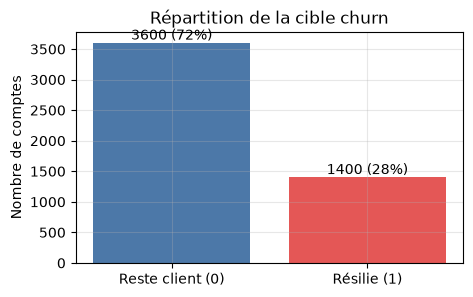

Taux de churn : 28.0% -> classes déséquilibrées (environ 1 compte sur 4 résilie)


In [6]:
from src.silver import clean_silver

silver, rapport_silver = clean_silver(brut, catalogue_brut, impute_medians=False)
silver["churn"] = silver["churn"].astype(int)          # cible binaire 0/1 (lue comme nombre décimal)
print(f"Vue typée : {silver.shape[0]} comptes (après suppression de {rapport_silver['n_doublons']} doublons)")

taux_churn = silver["churn"].mean()
fig, ax = plt.subplots(figsize=(5, 3))
comptes = silver["churn"].value_counts().sort_index()
ax.bar(["Reste client (0)", "Résilie (1)"], comptes.values,
       color=[COULEURS["non_churn"], COULEURS["churn"]])
for i, v in enumerate(comptes.values):
    ax.text(i, v, f"{v} ({v / len(silver):.0%})", ha="center", va="bottom")
ax.set_title("Répartition de la cible churn")
ax.set_ylabel("Nombre de comptes")
sauver_figure(fig, "01_repartition_cible")
plt.show()
print(f"Taux de churn : {taux_churn:.1%} -> classes déséquilibrées (environ 1 compte sur 4 résilie)")

**Lecture.** 28 % des comptes résilient. Les classes sont déséquilibrées : un modèle qui
prédirait « aucun churn » aurait 72 % d'exactitude sans rien apprendre. C'est pourquoi on
n'utilisera **pas l'exactitude** (accuracy) comme métrique, mais la **PR-AUC** (aire sous la
courbe précision-rappel), plus informative quand la classe d'intérêt est minoritaire, en
complément de la ROC-AUC exigée par l'énoncé.

📘 **Explication — valeurs manquantes**

On mesure, pour chaque colonne, la part de valeurs manquantes **après** conversion des types.
Ce chiffre est différent du nombre de cellules vides du §5 : une valeur illisible convertie
proprement n'est plus manquante, tandis qu'une cellule vide le reste.

`commentaire_csm` est traité à part : un texte vide n'est pas une valeur « manquante » au sens
statistique, c'est simplement l'absence de commentaire. Cette colonne n'entrera de toute façon
pas dans le modèle (D7).

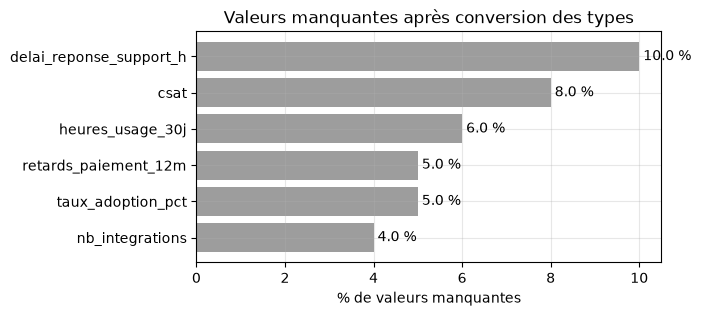

commentaire_csm vide : 55% des comptes


In [7]:
manquants = silver.drop(columns=["commentaire_csm"]).isna().mean().mul(100)
manquants = manquants[manquants > 0].sort_values()

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(manquants.index, manquants.values, color=COULEURS["neutre"])
for i, v in enumerate(manquants.values):
    ax.text(v, i, f" {v:.1f} %", va="center")
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes après conversion des types")
sauver_figure(fig, "02_valeurs_manquantes")
plt.show()
print(f"commentaire_csm vide : {(silver['commentaire_csm'].fillna('').str.strip() == '').mean():.0%} des comptes")

**Lecture.** Six variables ont entre 4 et 10 % de valeurs manquantes. C'est assez pour ne pas
supprimer les lignes concernées (on perdrait jusqu'à un tiers des comptes en cumulé), et assez
peu pour qu'une imputation simple soit raisonnable. La stratégie retenue, colonne par colonne,
est détaillée en §7.6.

📘 **Explication — pouvoir séparateur de chaque variable (AUC univariée)**

Pour chaque variable numérique prise **seule**, on calcule l'AUC ROC obtenue en l'utilisant
directement comme score de churn :

- **0,5** = la variable ne sépare pas du tout les comptes qui partent de ceux qui restent ;
- **1,0** = séparation parfaite.

On prend `max(AUC, 1 − AUC)` pour ne pas dépendre du sens de la relation (une ancienneté
*faible* est associée au churn, un nombre de tickets *élevé* aussi).

Pourquoi c'est utile :
1. **Détecter une fuite de données.** Une variable qui sépare presque parfaitement les deux
   classes est suspecte : elle contient souvent une information connue seulement *après* la
   résiliation. L'énoncé prévient qu'une AUC quasi parfaite « cache presque toujours une fuite ».
2. **Repérer les variables sans pouvoir prédictif**, candidates au statut de leurre.

In [8]:
from sklearn.metrics import roc_auc_score

VARIABLES_NUMERIQUES = [
    "anciennete_mois", "sieges_souscrits", "utilisateurs_actifs", "taux_adoption_pct",
    "connexions_30j", "heures_usage_30j", "fonctionnalites_total", "fonctionnalites_utilisees",
    "nb_integrations", "derniere_connexion_jours", "tickets_support_90j", "delai_reponse_support_h",
    "csat", "retards_paiement_12m", "revenu_mensuel_recurrent_eur", "sante_compte_fin_periode",
]
lignes = []
for col in VARIABLES_NUMERIQUES:
    valides = silver[[col, "churn"]].dropna()
    auc = roc_auc_score(valides["churn"], valides[col])
    lignes.append({"variable": col, "auc_univariee": round(max(auc, 1 - auc), 3),
                   "sens": "plus élevé = plus de churn" if auc >= 0.5 else "plus faible = plus de churn"})
auc_univ = pd.DataFrame(lignes).sort_values("auc_univariee", ascending=False).reset_index(drop=True)
display(auc_univ)

,variable,auc_univariee,sens
0,sante_compte_fin_periode,0.999,plus faible = plus de churn
1,nb_integrations,0.759,plus faible = plus de churn
2,anciennete_mois,0.714,plus faible = plus de churn
3,heures_usage_30j,0.697,plus faible = plus de churn
4,connexions_30j,0.696,plus faible = plus de churn
5,fonctionnalites_utilisees,0.692,plus faible = plus de churn
6,taux_adoption_pct,0.685,plus faible = plus de churn
7,csat,0.671,plus faible = plus de churn
8,derniere_connexion_jours,0.670,plus élevé = plus de churn
9,retards_paiement_12m,0.661,plus élevé = plus de churn


**Lecture — le piège de fuite.** `sante_compte_fin_periode` atteint une AUC de **0,999** à elle
seule, contre 0,53 à 0,76 pour toutes les autres variables. Son nom le confirme : un score de
santé calculé **en fin de période** est mesuré après la décision que le modèle doit anticiper.
Au moment réel du scoring, cette information n'existe pas encore. **Elle est exclue des deux
modèles** (churn et CLV), non parce qu'elle est trop corrélée, mais parce qu'elle **n'est pas
disponible au moment de la décision**. Elle reste dans la table Gold pour la traçabilité.

Les autres variables ont des AUC plausibles pour des signaux d'engagement observables avant
l'échéance (intégrations, ancienneté, usage, satisfaction).

📘 **Explication — distributions comparées**

Des boîtes à moustaches (*boxplots*) comparent la distribution de six variables entre les comptes
qui restent (bleu) et ceux qui partent (rouge). La boîte contient la moitié centrale des
valeurs, le trait central est la médiane.

On cherche des différences **visibles et interprétables par le métier** : si elles existent, le
modèle a quelque chose à apprendre, et on pourra expliquer ses résultats aux CSM.

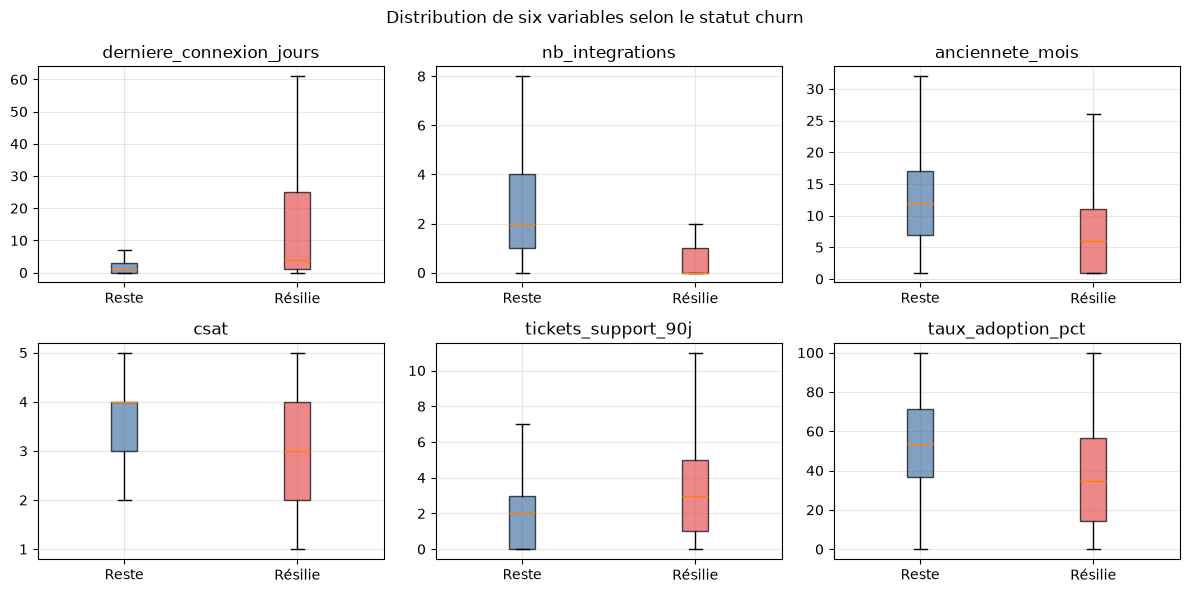

churn,médiane reste,médiane résilie
derniere_connexion_jours,1.0,4.0
nb_integrations,2.0,0.0
anciennete_mois,12.0,6.0
csat,4.0,3.0
tickets_support_90j,2.0,3.0
taux_adoption_pct,53.6,34.5


In [9]:
variables_cles = ["derniere_connexion_jours", "nb_integrations", "anciennete_mois",
                  "csat", "tickets_support_90j", "taux_adoption_pct"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.ravel(), variables_cles):
    donnees = [silver.loc[silver["churn"] == k, col].dropna() for k in (0, 1)]
    boites = ax.boxplot(donnees, patch_artist=True, showfliers=False)
    for boite, couleur in zip(boites["boxes"], [COULEURS["non_churn"], COULEURS["churn"]]):
        boite.set_facecolor(couleur)
        boite.set_alpha(0.7)
    ax.set_xticks([1, 2], ["Reste", "Résilie"])
    ax.set_title(col)
fig.suptitle("Distribution de six variables selon le statut churn")
fig.tight_layout()
sauver_figure(fig, "03_distributions_par_churn")
plt.show()
display(silver.groupby("churn")[variables_cles].median().T.rename(columns={0: "médiane reste", 1: "médiane résilie"}))

**Lecture.** Les comptes qui résilient se connectent moins récemment, ont moins
d'intégrations, sont plus récents, moins satisfaits (CSAT), ouvrent plus de tickets et adoptent
moins la plateforme. Ces signaux ont un **sens métier clair** : ce sont exactement ceux qu'un
CSM expérimenté surveille. Le modèle devra les combiner.

📘 **Explication — identifier les leurres par un test statistique**

L'énoncé annonce des **variables leurres** : sans pouvoir prédictif, à identifier et à exclure.
On ne les choisit pas « à l'œil » : on applique un test adapté au type de chaque variable.

- **Variables numériques** : corrélation *point-bisériale* avec `churn` (c'est une corrélation
  de Pearson quand l'une des deux variables est binaire). Seuil : |r| < 0,03.
- **Variables catégorielles** : **V de Cramér**, calculé à partir du test du χ² d'indépendance.
  Il mesure la *force* de l'association entre 0 (aucune) et 1 (totale). On l'utilise plutôt
  que la seule p-value, parce qu'avec 5 000 lignes une association minuscule peut être
  « significative » sans avoir aucun intérêt pratique. Seuil : V < 0,05.

La fonction `identify_leurres` de `src/gold.py` applique ces deux tests. Pour ce test
descriptif, les valeurs manquantes sont remplacées temporairement par la médiane (le calcul de
corrélation ne les accepte pas).

In [10]:
from scipy import stats
from src.gold import CATEGORICAL_CANDIDATES, NUMERIC_CANDIDATES, cramers_v, identify_leurres

silver_test = silver.fillna(silver[NUMERIC_CANDIDATES].median())
leurres_detectes = identify_leurres(silver_test)

tests = []
for col in NUMERIC_CANDIDATES:
    r = stats.pointbiserialr(silver_test["churn"], silver_test[col].astype(float))[0]
    tests.append({"variable": col, "type": "numérique", "test": "corrélation point-bisériale",
                  "effet": round(abs(r), 3), "leurre": col in leurres_detectes})
for col in CATEGORICAL_CANDIDATES:
    v = cramers_v(pd.crosstab(silver_test[col], silver_test["churn"]).values)
    tests.append({"variable": col, "type": "catégorielle", "test": "V de Cramér",
                  "effet": round(v, 3), "leurre": col in leurres_detectes})
tests = pd.DataFrame(tests).sort_values(["leurre", "effet"], ascending=[False, True]).reset_index(drop=True)
display(tests)
print("Variables signalées par le test :", leurres_detectes)

,variable,type,test,effet,leurre
0,groupe_experimentation,catégorielle,V de Cramér,0.004,True
1,couleur_theme_interface,catégorielle,V de Cramér,0.015,True
2,code_datacenter,catégorielle,V de Cramér,0.019,True
3,sieges_souscrits,numérique,corrélation point-bisériale,0.029,True
4,pays,catégorielle,V de Cramér,0.035,True
5,jour_souscription,catégorielle,V de Cramér,0.045,True
6,revenu_mensuel_recurrent_eur,numérique,corrélation point-bisériale,0.047,False
7,secteur,catégorielle,V de Cramér,0.052,False
8,taille_entreprise,catégorielle,V de Cramér,0.068,False
9,utilisateurs_actifs,numérique,corrélation point-bisériale,0.113,False


Variables signalées par le test : ['sieges_souscrits', 'pays', 'jour_souscription', 'couleur_theme_interface', 'code_datacenter', 'groupe_experimentation']


📘 **Explication — visualiser un leurre**

Un leurre catégoriel se reconnaît facilement sur un graphique : le taux de churn est le même
dans toutes ses modalités. On compare quatre leurres (couleur du thème, datacenter, groupe
d'A/B test, jour de souscription) à deux variables réellement liées au churn (taille
d'entreprise, plan). La ligne pointillée représente le taux de churn global (28 %).

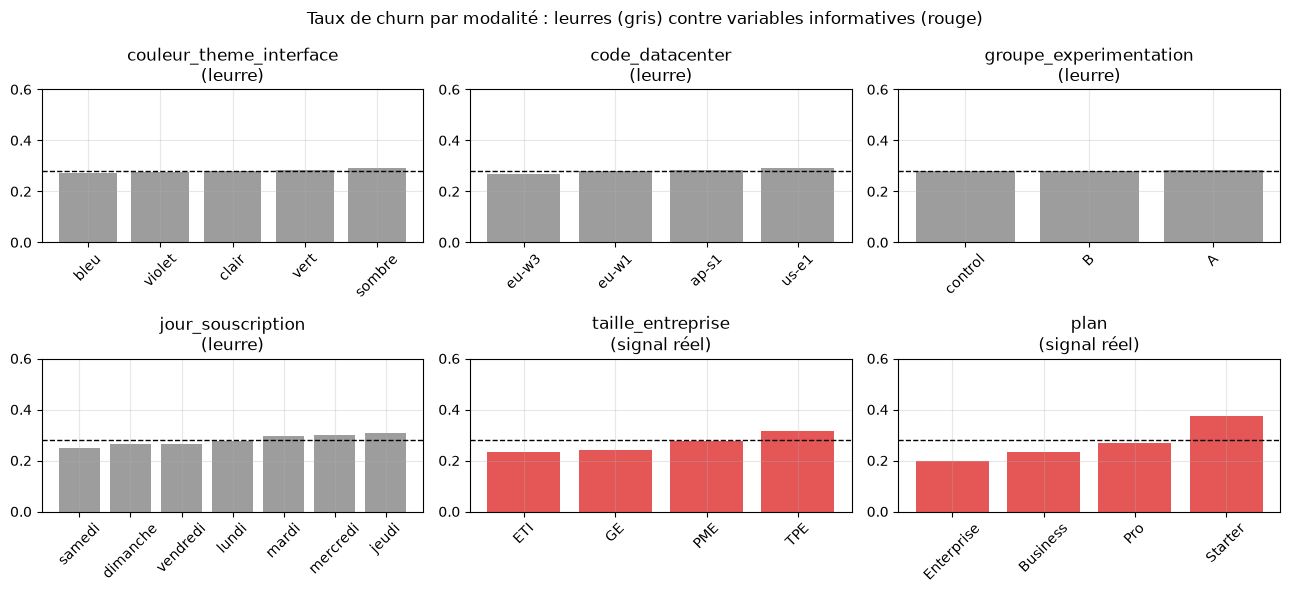

In [11]:
a_comparer = ["couleur_theme_interface", "code_datacenter", "groupe_experimentation",
              "jour_souscription", "taille_entreprise", "plan"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), a_comparer):
    taux = silver.groupby(col)["churn"].mean().sort_values()
    couleur = COULEURS["neutre"] if col in leurres_detectes else COULEURS["churn"]
    ax.bar(taux.index.astype(str), taux.values, color=couleur)
    ax.axhline(taux_churn, linestyle="--", color="black", linewidth=1)
    ax.set_ylim(0, 0.6)
    ax.set_title(f"{col}\n({'leurre' if col in leurres_detectes else 'signal réel'})")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Taux de churn par modalité : leurres (gris) contre variables informatives (rouge)")
fig.tight_layout()
sauver_figure(fig, "04_leurres_vs_signal")
plt.show()

**Lecture — les leurres.** Le test signale **six** variables : les cinq variables sans lien
plausible avec la résiliation (`jour_souscription`, `pays`, `code_datacenter`,
`couleur_theme_interface`, `groupe_experimentation`) et `sieges_souscrits`.

- Les **cinq premières sont exclues** du modèle (§7.8), comme le demande l'énoncé. Le §8
  vérifie en validation croisée que les retirer ne coûte rien.
- **`sieges_souscrits` est conservée** : sa corrélation *directe* avec le churn est nulle, mais
  c'est une variable métier centrale (taille du contrat), qui porte l'information de la
  régression CLV et entre dans le calcul du taux d'adoption. Un test univarié ne voit pas ces
  interactions : on vérifie en §8 que la garder ne dégrade pas le modèle.

📘 **Explication — redondances entre variables**

Deux variables qui disent la même chose n'apportent rien de plus au modèle, et elles gênent un
modèle linéaire : ses coefficients deviennent instables et difficiles à interpréter
(*colinéarité*). On vérifie deux sources de redondance :

1. **Les colonnes du catalogue** (prix par siège, SLA, quota…) : si chacune ne prend qu'une
   seule valeur par plan, elle n'apporte aucune information au-delà de `plan`.
2. **Les corrélations entre variables numériques**, affichées en carte de chaleur : plus la
   case est foncée, plus les deux variables sont liées.

Nombre maximal de valeurs distinctes par plan :
prix_mensuel_par_siege_eur    1
fonctionnalites_incluses      1
sla_reponse_h                 1
quota_stockage_go             1
support_dedie                 1
fonctionnalites_total         1
fonctionnalites_total == fonctionnalites_incluses sur 100% des comptes


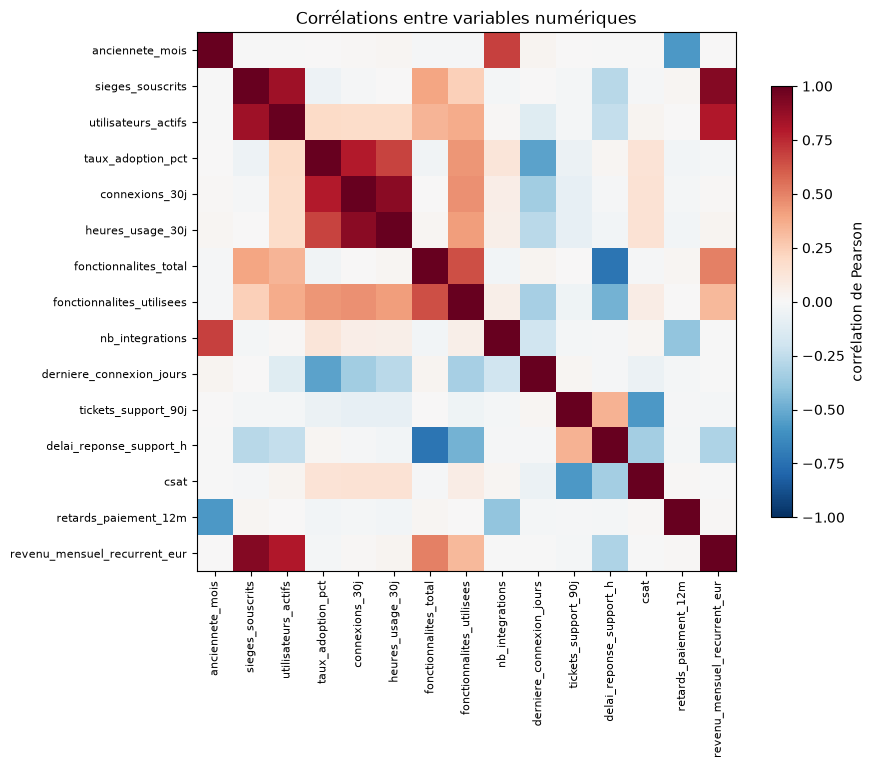

Paires les plus corrélées :
sieges_souscrits     revenu_mensuel_recurrent_eur    0.92
connexions_30j       heures_usage_30j                0.90
sieges_souscrits     utilisateurs_actifs             0.85
utilisateurs_actifs  revenu_mensuel_recurrent_eur    0.80
taux_adoption_pct    connexions_30j                  0.80


In [12]:
colonnes_catalogue = ["prix_mensuel_par_siege_eur", "fonctionnalites_incluses", "sla_reponse_h",
                      "quota_stockage_go", "support_dedie", "fonctionnalites_total"]
valeurs_par_plan = silver.groupby("plan")[colonnes_catalogue].nunique().max()
print("Nombre maximal de valeurs distinctes par plan :")
print(valeurs_par_plan.to_string())
print("fonctionnalites_total == fonctionnalites_incluses sur",
      f"{(silver['fonctionnalites_total'] == silver['fonctionnalites_incluses']).mean():.0%} des comptes")

numeriques = [c for c in VARIABLES_NUMERIQUES if c != "sante_compte_fin_periode"]
correlations = silver[numeriques].corr()
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(correlations, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeriques)), numeriques, rotation=90, fontsize=8)
ax.set_yticks(range(len(numeriques)), numeriques, fontsize=8)
fig.colorbar(image, ax=ax, shrink=0.8, label="corrélation de Pearson")
ax.set_title("Corrélations entre variables numériques")
ax.grid(False)
sauver_figure(fig, "05_correlations")
plt.show()
paires = (correlations.where(np.triu(np.ones(correlations.shape, dtype=bool), k=1)).stack()
          .abs().sort_values(ascending=False).head(5))
print("Paires les plus corrélées :")
print(paires.round(2).to_string())

**Lecture.** Les cinq colonnes issues du catalogue ne prennent **qu'une valeur par plan** :
elles répètent l'information de `plan` sous une autre forme. Elles sont exclues (§7.8). En
revanche, `fonctionnalites_total` est gardée (identique à `fonctionnalites_incluses`, on n'en
conserve qu'une) car elle sert au ratio d'utilisation des fonctionnalités. Les fortes
corrélations entre sièges, utilisateurs actifs et usage sont attendues (un gros compte a plus
d'utilisateurs et plus d'usage) ; la régularisation de la régression logistique les gère.

📘 **Explication — examen critique de la variable la plus prédictive**

`derniere_connexion_jours` (nombre de jours depuis la dernière connexion) est l'une des
variables les plus liées au churn. Avant de lui faire confiance, on vérifie qu'elle n'est pas
elle aussi une fuite déguisée : si elle était mesurée *à l'échéance*, un client ayant déjà
décidé de partir aurait arrêté de se connecter, et la variable « connaîtrait » la décision.

L'histogramme compare les deux groupes et la cellule cherche une zone de séparation parfaite.

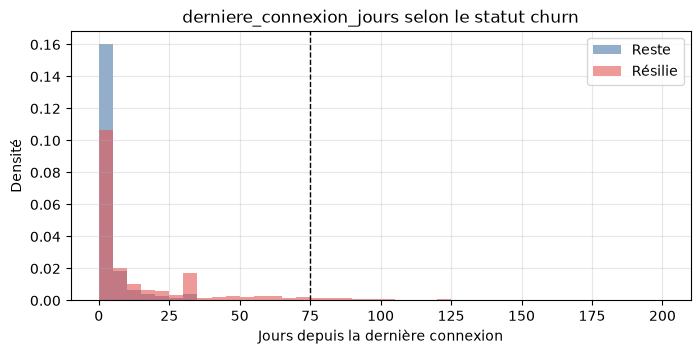

Maximum observé chez les comptes fidèles : 75 jours
Comptes au-delà de ce maximum : 82 (1.6%), dont churn : 100%
AUC univariée : 0.67


In [13]:
fig, ax = plt.subplots(figsize=(8, 3.5))
bornes = np.arange(0, 205, 5)
for k, nom in [(0, "non_churn"), (1, "churn")]:
    ax.hist(silver.loc[silver["churn"] == k, "derniere_connexion_jours"], bins=bornes, alpha=0.6,
            color=COULEURS[nom], label="Reste" if k == 0 else "Résilie", density=True)
max_fideles = silver.loc[silver["churn"] == 0, "derniere_connexion_jours"].max()
ax.axvline(max_fideles, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Jours depuis la dernière connexion")
ax.set_ylabel("Densité")
ax.legend()
ax.set_title("derniere_connexion_jours selon le statut churn")
sauver_figure(fig, "06_derniere_connexion")
plt.show()
au_dela = silver["derniere_connexion_jours"] > max_fideles
print(f"Maximum observé chez les comptes fidèles : {max_fideles:.0f} jours")
print(f"Comptes au-delà de ce maximum : {au_dela.sum()} ({au_dela.mean():.1%}), dont churn : {silver.loc[au_dela, 'churn'].mean():.0%}")
print(f"AUC univariée : {auc_univ.set_index('variable').loc['derniere_connexion_jours', 'auc_univariee']}")

**Lecture.** Au-delà de 75 jours sans connexion, tous les comptes observés résilient. Mais cela
ne concerne qu'une petite part des comptes, et l'AUC de la variable (0,67) reste très loin de la
séparation quasi parfaite du piège de fuite (0,999). Le dictionnaire la décrit comme « jours
depuis la dernière connexion », un signal de désengagement observable au moment du scoring
mensuel. **Je la conserve**, avec une réserve explicite : dans un déploiement réel, il faudrait
confirmer auprès du propriétaire de la donnée qu'elle est bien calculée à la date du scoring,
et non à l'échéance (point listé en §14).

### 📓 Journal de bord — §6 Analyse exploratoire [C3]

- **Cible déséquilibrée** (28 % de churn) : métriques retenues = PR-AUC (principale) et ROC-AUC,
  jamais l'exactitude seule.
- **Valeurs manquantes** : 6 variables entre 4 et 10 % ; imputation dans le pipeline, pas de
  suppression de lignes.
- **Piège de fuite** : `sante_compte_fin_periode`, AUC univariée de 0,999, calculée en fin de
  période donc indisponible au scoring → exclue des deux modèles.
- **Leurres** : 5 variables sans lien plausible et sans effet mesurable → exclues. Une sixième
  (`sieges_souscrits`) est signalée par le test mais conservée pour sa valeur métier, sous
  réserve de vérification en §8.
- **Redondances** : 5 colonnes du catalogue répètent `plan` → exclues.
- **Signaux métier** : récence de connexion, intégrations, ancienneté, satisfaction, tickets,
  adoption. Tous interprétables par un CSM.
- **Point de vigilance** : `derniere_connexion_jours` sépare parfaitement au-delà de 75 jours ;
  conservée, avec une vérification de sa date de calcul à prévoir en situation réelle.

## 7. Préparation des données — journal de bord [C3]

Chaque transformation est une fonction de `src/` couverte par des tests unitaires : la même
logique sert à l'entraînement et au scoring en production, sans copier-coller.

📘 **Explication — 7.1 à 7.3 : doublons, dates, nombres écrits en texte**

La cellule démontre chaque correction sur des exemples concrets :

- **Doublons** : `drop_strict_duplicates` supprime les lignes identiques sur toutes les colonnes
  métier. Les colonnes de traçabilité sont exclues de la comparaison, sinon deux copies
  ingérées à des instants différents ne seraient jamais reconnues comme doublons.
- **Dates** : `parse_date_multi` essaie successivement les trois formats rencontrés
  (`AAAA-MM-JJ`, `JJ/MM/AAAA`, `JJ Mon AAAA`). On vérifie qu'aucune date ne reste illisible. La
  date n'entre pas dans le modèle (l'ancienneté en mois porte déjà cette information), mais
  elle est conservée pour la traçabilité.
- **Nombres en texte** : `parse_numeric_fr` retire les symboles (`%`, `€`, `h`), remplace la
  virgule décimale par un point, puis convertit. La démonstration compare avec la conversion
  naïve de pandas, qui transforme silencieusement ces valeurs en manquantes : un bug classique
  qui gonflerait artificiellement le taux de valeurs manquantes.

In [14]:
from src.silver import drop_strict_duplicates, parse_date_multi, parse_numeric_fr

_, n_supprimes = drop_strict_duplicates(brut)
print(f"7.1 Doublons stricts supprimés : {n_supprimes}")

dates = parse_date_multi(brut["date_souscription"])
exemples_dates = brut["date_souscription"].drop_duplicates().head(3)
print(f"7.2 Dates illisibles après lecture multi-formats : {int(dates.isna().sum())}")
print("    exemples :", dict(zip(exemples_dates, parse_date_multi(exemples_dates).dt.date.astype(str))))

exemples = pd.Series(["12,5 %", "990,0 €", "2 h", "37.5", ""])
demo = pd.DataFrame({
    "valeur brute": exemples,
    "pd.to_numeric naïf": pd.to_numeric(exemples, errors="coerce"),
    "parse_numeric_fr": parse_numeric_fr(exemples),
})
print("7.3 Conversion des nombres écrits en texte :")
display(demo)

7.1 Doublons stricts supprimés : 35
7.2 Dates illisibles après lecture multi-formats : 0
    exemples : {'31/01/2024': '2024-01-31', '2024-02-06': '2024-02-06', '23 Dec 2024': '2024-12-23'}
7.3 Conversion des nombres écrits en texte :


,valeur brute,pd.to_numeric naïf,parse_numeric_fr
0,"12,5 %",NaN,12.5
1,"990,0 €",NaN,990.0
2,2 h,NaN,2.0
3,37.5,37.5,37.5
4,,NaN,NaN


📘 **Explication — 7.4 et 7.5 : catégories et jointure avec le catalogue**

- **Normalisation des catégories** : `plan` et `taille_entreprise` sont mis dans une casse unique
  et débarrassés des espaces. Pour `secteur`, dont les accents ont été corrompus à l'encodage
  (`SantÃ©`), réparer l'encodage n'est pas fiable : on reconnaît chaque secteur par un morceau
  de mot qui ne contient pas d'accent (`SANT` → Santé, `DUCATION` → Éducation).
- **Jointure** : une fois `plan` normalisé des deux côtés, chaque compte doit retrouver son plan
  dans le catalogue. On vérifie qu'il n'y a **aucun orphelin** (compte sans plan correspondant).

La cellule affiche les valeurs de `secteur` avant et après normalisation.

In [15]:
avant = brut["secteur"].value_counts().head(10)
apres = silver["secteur"].value_counts()
print("7.4 secteur, 10 valeurs brutes les plus fréquentes :", avant.index.tolist())
print("    après normalisation :", apres.to_dict())
print(f"7.5 Comptes sans plan correspondant dans le catalogue : {rapport_silver['n_orphelins_catalogue']}")

7.4 secteur, 10 valeurs brutes les plus fréquentes : ['Commerce', 'Tech', 'Finance', 'Industrie', 'Éducation', 'Santé', '', 'Public', 'COMMERCE', 'commerce']
    après normalisation : {'Commerce': 905, 'Tech': 861, 'Finance': 769, 'Industrie': 666, 'Éducation': 583, 'Santé': 568, 'Public': 398, 'Inconnu': 250}
7.5 Comptes sans plan correspondant dans le catalogue : 0


### 7.6 Stratégie de traitement des valeurs manquantes

Une décision par colonne, et non une imputation uniforme :

| Colonne(s) | Manquants | Traitement | Justification |
|---|---|---|---|
| `revenu_mensuel_recurrent_eur` | recalculé | sièges × prix catalogue du plan | Valeur reconstituable exactement par une règle métier |
| `taux_adoption_pct` | 5 % | **recalculé** : 100 × actifs / sièges | Définition même de la variable (écart moyen de 0,02 point sur les valeurs connues) |
| `secteur`, `pays` | quelques % | modalité explicite « Inconnu » | Ne pas inventer une catégorie ; l'absence reste visible |
| `heures_usage_30j`, `nb_integrations`, `delai_reponse_support_h`, `csat`, `retards_paiement_12m` | 4 à 10 % | **médiane, calculée dans le pipeline sur le seul jeu d'entraînement** | Robuste aux valeurs extrêmes ; calculée après le découpage pour ne pas utiliser d'information du test |
| `commentaire_csm` | 55 % vides | non traité | Exclu du modèle (D7) |

**Changement par rapport à la v1** : la v1 calculait les médianes sur les 5 000 comptes avant le
découpage train/test. La fuite d'information était minime, mais réelle ; elle est corrigée ici.
Des indicateurs de valeur manquante (« csat absent ») ont aussi été testés en §8 : ils
n'apportent rien et ne sont pas retenus.

📘 **Explication — 7.7 et 7.8 : construction des features du Gold v2**

`construire_features_v2` (module `src/features.py`) produit les 20 variables du modèle :

1. elle **recalcule** `taux_adoption_pct` quand il manque ;
2. elle ajoute deux **ratios métier** déjà présents en v1 :
   - `taux_utilisation_fonctionnalites` = fonctionnalités utilisées / fonctionnalités offertes ;
   - `taux_retard_paiement_par_mois` = retards de paiement / ancienneté, pour comparer des
     comptes d'âges différents ;
3. elle ne garde que les colonnes autorisées, dans un ordre fixe.

La cellule affiche le tableau récapitulatif des colonnes **exclues**, chacune avec sa raison :
l'énoncé demande de justifier chaque exclusion.

D'autres ratios ont été essayés (connexions par utilisateur actif, sièges inutilisés, remise
par rapport au prix catalogue…) : le §8 montre qu'ils n'améliorent pas le modèle ; ils ne sont
donc pas retenus. Essayer une idée n'oblige pas à la garder.

In [16]:
from src.features import (CATEGORIELLES_V2, FEATURES_V2, LEURRES, NUMERIQUES_V2,
                          REDONDANTES_CATALOGUE, construire_features_v2)

features = construire_features_v2(silver)
print(f"{len(FEATURES_V2)} features retenues : {len(CATEGORIELLES_V2)} catégorielles, {len(NUMERIQUES_V2)} numériques")
print("taux_adoption_pct manquants : avant", int(silver["taux_adoption_pct"].isna().sum()),
      "-> après recalcul", int(features["taux_adoption_pct"].isna().sum()))

exclusions = pd.DataFrame(
    [("client_id", "identifiant", "aucune valeur prédictive légitime")]
    + [("date_souscription", "redondante", "information portée par anciennete_mois")]
    + [("commentaire_csm", "conformité (D7)", "texte libre, risque de données personnelles")]
    + [("sante_compte_fin_periode", "fuite de données", "calculée en fin de période : indisponible au scoring (AUC 0,999)")]
    + [("valeur_vie_client_eur", "cible secondaire", "interdite comme variable explicative du churn (énoncé §3.2)")]
    + [(c, "leurre", "aucun effet mesurable sur le churn (§6)") for c in LEURRES]
    + [(c, "redondante (catalogue)", "une seule valeur par plan : répète l'information de plan") for c in REDONDANTES_CATALOGUE],
    columns=["colonne exclue", "catégorie", "raison"],
)
display(exclusions)

20 features retenues : 3 catégorielles, 17 numériques
taux_adoption_pct manquants : avant 250 -> après recalcul 0


,colonne exclue,catégorie,raison
0,client_id,identifiant,aucune valeur prédictive légitime
1,date_souscription,redondante,information portée par anciennete_mois
2,commentaire_csm,conformité (D7),"texte libre, risque de données personnelles"
3,sante_compte_fin_periode,fuite de données,calculée en fin de période : indisponible au s...
4,valeur_vie_client_eur,cible secondaire,interdite comme variable explicative du churn ...
5,jour_souscription,leurre,aucun effet mesurable sur le churn (§6)
6,pays,leurre,aucun effet mesurable sur le churn (§6)
7,code_datacenter,leurre,aucun effet mesurable sur le churn (§6)
8,couleur_theme_interface,leurre,aucun effet mesurable sur le churn (§6)
9,groupe_experimentation,leurre,aucun effet mesurable sur le churn (§6)


📘 **Explication — 7.9 : découpage entraînement / test**

`assign_split` (module `src/gold.py`) découpe les comptes en **80 % d'entraînement** et **20 % de
test**, de façon :

- **stratifiée** : le taux de churn est le même (28 %) dans les deux parties ; sans cela, le
  hasard pourrait mettre plus de comptes qui partent d'un côté et fausser l'évaluation ;
- **reproductible** : graine fixe (42), donc le même découpage à chaque exécution.

Le découpage est **matérialisé par une colonne `split`** dans la table Gold, au lieu d'être
recalculé à chaque fois : n'importe qui peut vérifier sur quels comptes le modèle a été testé.
On vérifie enfin que ce découpage est **identique à celui de la v1** : les résultats v1 et v2
sont donc comparables compte par compte.

In [17]:
from src.gold import assign_split

silver["split"] = assign_split(silver, test_size=0.2, random_state=RANDOM_STATE)
recap = silver.groupby("split")["churn"].agg(comptes="size", taux_churn="mean")
display(recap.style.format({"taux_churn": "{:.1%}"}))

gold_v1 = pd.read_parquet(GOLD_DIR / "clients_churn_gold.parquet")[["client_id", "split"]]
identique = silver[["client_id", "split"]].merge(gold_v1, on="client_id", suffixes=("_v2", "_v1"))
print("Découpage identique à celui de la v1 :", bool((identique["split_v2"] == identique["split_v1"]).all()))

,comptes,taux_churn
split,,
test,1000,28.0%
train,4000,28.0%


Découpage identique à celui de la v1 : True


📘 **Explication — 7.10 : persistance du Gold v2 et de son manifeste**

On enregistre la table Gold v2 au format **Parquet** (format en colonnes, typé et compressé),
avec :

- les 20 features, la colonne `split` et les deux cibles ;
- `sante_compte_fin_periode`, conservée **pour la traçabilité uniquement** (elle n'est jamais
  donnée aux modèles).

Un **manifeste JSON** accompagne le fichier : version, date, hash SHA-256 des sources et du
fichier produit, commit Git du code, liste des features et des exclusions. Une **fiche
d'identité** en Markdown explique les changements par rapport à la v1. La v1 n'est pas écrasée :
les deux versions coexistent, et MLflow permet de comparer les modèles entraînés sur chacune.

In [18]:
from src.versioning import write_manifest

gold_v2 = pd.concat(
    [silver[["client_id", "split"]], features,
     silver[["sante_compte_fin_periode", "valeur_vie_client_eur", "churn"]]], axis=1)
chemin_gold_v2 = GOLD_DIR / "clients_churn_gold_v2.parquet"
gold_v2.to_parquet(chemin_gold_v2, index=False)
sha_gold_v2 = sha256_of(chemin_gold_v2)

manifeste_gold_v2 = {
    "couche": "gold", "version": "v2",
    "processed_at_utc": datetime.now(timezone.utc).isoformat(),
    "produit_par": "notebooks/notebook_certifiant_churn_saas.ipynb", "commit_git": commit_git(),
    "sources": {p.name: sha256_of(p) for p in FICHIERS_SOURCES.values() if p.name != "churn_saas_echantillon.csv"},
    "sha256_gold": sha_gold_v2, "lignes": int(len(gold_v2)),
    "features_modele": FEATURES_V2,
    "colonnes_exclues": exclusions.set_index("colonne exclue")["catégorie"].to_dict(),
    "imputation": "médiane dans le pipeline sklearn, ajustée sur le train ; taux_adoption_pct recalculé",
    "split": {"random_state": RANDOM_STATE, "test_size": 0.2, "stratifie_sur": "churn",
              "taux_churn_train": round(float(recap.loc["train", "taux_churn"]), 4),
              "taux_churn_test": round(float(recap.loc["test", "taux_churn"]), 4),
              "identique_v1": True},
}
write_manifest(GOLD_DIR / "gold_v2_manifest.json", manifeste_gold_v2)

fiche = f"""# Fiche d'identité — Gold dataset v2

Produit par `notebooks/notebook_certifiant_churn_saas.ipynb` (commit `{commit_git()}`).
Fichier : `data/gold/clients_churn_gold_v2.parquet` — SHA-256 `{sha_gold_v2}`.

## Changements par rapport à la v1
- 5 leurres exclus ({", ".join(LEURRES)}) : effet nul sur le churn, exclusion demandée par l'énoncé.
- 5 colonnes du catalogue exclues ({", ".join(REDONDANTES_CATALOGUE)}) : une valeur par plan.
- Imputation par la médiane déplacée dans le pipeline (ajustée sur le train) : plus de fuite train/test.
- `taux_adoption_pct` manquant recalculé (100 × actifs / sièges) au lieu d'être imputé.

## Inchangé
- Même découpage train/test que la v1 (graine 42, stratifié) : comparaison compte par compte possible.
- `sante_compte_fin_periode` conservée pour traçabilité, jamais utilisée par les modèles.

## Composition
{len(gold_v2)} comptes, {len(FEATURES_V2)} features, taux de churn {taux_churn:.1%}.
"""
(GOLD_DIR / "gold_fiche_identite_v2.md").write_text(fiche, encoding="utf-8")
print(f"Gold v2 : {gold_v2.shape[0]} lignes x {gold_v2.shape[1]} colonnes -> {chemin_gold_v2.relative_to(ROOT)}")
print(f"SHA-256 : {sha_gold_v2}")

Gold v2 : 5000 lignes x 25 colonnes -> data\gold\clients_churn_gold_v2.parquet
SHA-256 : d443920d4245d3c6bd7e2605151402345a4d074b787a585743dcc32719001a3e


### 📓 Journal de bord — §7 Préparation [C3]

- **Nettoyage** : 35 doublons supprimés, 0 date illisible, nombres en texte convertis (le bug de
  la conversion naïve est démontré), secteurs normalisés, 0 orphelin après jointure.
- **Valeurs manquantes** : une stratégie par colonne ; MRR et taux d'adoption **recalculés** par
  règle métier ; médianes calculées **dans le pipeline, sur le seul train** (correction d'une
  fuite minime de la v1).
- **Features** : 20 variables (3 catégorielles, 17 numériques, dont 2 ratios métier).
- **Exclusions justifiées** : identifiant, date, texte libre (D7), fuite, cible secondaire,
  5 leurres, 5 redondances.
- **Découpage** : 80/20 stratifié, graine 42, identique à la v1, matérialisé dans la table.
- **Versioning** : Gold v2 enregistré avec son manifeste (hashes, commit) et sa fiche
  d'identité, sans écraser la v1.

## 8. Choix du modèle et démarche scientifique — journal de bord [C4]

### 8.1 Protocole

- **Données** : uniquement le jeu d'entraînement (4 000 comptes). Le jeu de test reste fermé
  jusqu'au §9.
- **Validation croisée stratifiée à 5 plis** : l'entraînement est découpé en 5 parts ; chaque
  modèle est entraîné 5 fois sur 4 parts et évalué sur la cinquième. On obtient 5 scores, donc
  une moyenne **et une dispersion** : on sait si un écart entre deux modèles est réel ou dû au
  hasard du découpage.
- **Métrique principale** : PR-AUC (classes déséquilibrées) ; ROC-AUC en complément (exigée par
  l'énoncé).
- **Règle de sélection fixée à l'avance** : le meilleur score moyen, sauf si un modèle plus
  simple et plus explicable fait jeu égal (écart inférieur à un écart-type).
- **Critère d'acceptation D8** : battre la baseline métier d'au moins +0,15 de PR-AUC.

📘 **Explication — préparer les données et le pipeline de modélisation**

1. On sépare la table Gold v2 en **entraînement** et **test** grâce à la colonne `split`.
2. On définit un **pipeline** scikit-learn : une chaîne d'étapes appliquées toujours dans le
   même ordre, à l'entraînement comme à la prédiction :
   - variables catégorielles → **encodage one-hot** (une colonne 0/1 par modalité ; une
     modalité inconnue à la prédiction est ignorée au lieu de provoquer une erreur) ;
   - variables numériques → **imputation par la médiane** puis **standardisation** (centrer et
     réduire : chaque variable a une moyenne de 0 et un écart-type de 1, ce qui rend les
     coefficients d'un modèle linéaire comparables entre eux) ;
   - puis le **modèle**.
3. Point essentiel : dans la validation croisée, le pipeline complet est réentraîné à chaque
   pli. La médiane d'imputation et les paramètres de standardisation sont donc calculés **sur
   les seules données d'entraînement du pli** : aucune information du pli de validation ne
   fuit dans la préparation.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

train = gold_v2[gold_v2["split"] == "train"].reset_index(drop=True)
test = gold_v2[gold_v2["split"] == "test"].reset_index(drop=True)
X_train, y_train = train[FEATURES_V2], train["churn"]
X_test, y_test = test[FEATURES_V2], test["churn"]
print(f"Entraînement : {X_train.shape}, churn {y_train.mean():.1%} | Test : {X_test.shape}, churn {y_test.mean():.1%}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"pr_auc": "average_precision", "roc_auc": "roc_auc"}


def preprocesseur(categorielles, numeriques, standardiser=True, indicateurs=False):
    """One-hot des catégorielles ; imputation médiane (+ standardisation) des numériques."""
    etapes_num = [("imputation", SimpleImputer(strategy="median", add_indicator=indicateurs))]
    if standardiser:
        etapes_num.append(("standardisation", StandardScaler()))
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorielles),
        ("num", Pipeline(etapes_num), numeriques),
    ])


def pipeline_modele(estimateur, categorielles=CATEGORIELLES_V2, numeriques=NUMERIQUES_V2,
                    standardiser=True, indicateurs=False):
    return Pipeline([
        ("preparation", preprocesseur(categorielles, numeriques, standardiser, indicateurs)),
        ("modele", estimateur),
    ])


def evaluer_cv(nom, pipeline, X=X_train):
    """Validation croisée 5 plis : moyenne et écart-type de la PR-AUC et de la ROC-AUC."""
    res = cross_validate(pipeline, X, y_train, cv=cv, scoring=SCORING)
    return {"modèle": nom, "pr_auc": res["test_pr_auc"].mean(), "pr_auc_std": res["test_pr_auc"].std(),
            "roc_auc": res["test_roc_auc"].mean(), "plis": res["test_pr_auc"]}

Entraînement : (4000, 20), churn 28.0% | Test : (1000, 20), churn 28.0%

### 8.2 Les baselines : ce que l'on sait faire sans modèle

Deux références, à battre nettement :

1. **Baseline naïve** (`DummyClassifier`) : prédit pour tous les comptes la même probabilité,
   le taux de churn moyen. Sa PR-AUC vaut le taux de base (≈ 0,28) : c'est le plancher absolu.
2. **Baseline métier (D8)** : une règle qu'un CSM pourrait appliquer à la main. D8 la décrit
   comme une « règle sur ancienneté et santé du compte ». **Attention** : le score de santé
   disponible (`sante_compte_fin_periode`) est la variable de fuite ; l'utiliser donnerait une
   baseline impossible à battre et, surtout, inapplicable au moment du scoring. J'interprète
   donc la « santé » par des signaux d'engagement **observables avant l'échéance** : nombre
   d'intégrations et récence de connexion. La règle, sans aucun apprentissage :

   `score = − ancienneté / 36 − intégrations / 16 + jours_depuis_connexion / 200`

   (chaque terme est ramené à une échelle de 0 à 1 par le maximum du dictionnaire de données).

📘 **Explication — évaluer les baselines**

- Le `DummyClassifier(strategy="prior")` est évalué avec la même validation croisée que les
  modèles.
- La règle métier n'apprend rien, mais on la mesure **sur les mêmes plis de validation** pour
  que la comparaison soit équitable. Les intégrations manquantes sont remplacées par la médiane
  du pli d'entraînement (même principe que dans le pipeline).

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score


def score_regle_metier(df, mediane_integrations):
    """Baseline D8 : ancienneté faible, peu d'intégrations, connexion ancienne = risque."""
    return (-df["anciennete_mois"] / 36
            - df["nb_integrations"].fillna(mediane_integrations) / 16
            + df["derniere_connexion_jours"] / 200)


resultats_cv = [evaluer_cv("Baseline naïve (Dummy)", DummyClassifier(strategy="prior"))]
plis_regle, plis_regle_roc = [], []
for idx_app, idx_val in cv.split(X_train, y_train):
    mediane = X_train.iloc[idx_app]["nb_integrations"].median()
    score = score_regle_metier(X_train.iloc[idx_val], mediane)
    plis_regle.append(average_precision_score(y_train.iloc[idx_val], score))
    plis_regle_roc.append(roc_auc_score(y_train.iloc[idx_val], score))
resultats_cv.append({"modèle": "Baseline métier D8 (règle)", "pr_auc": np.mean(plis_regle),
                     "pr_auc_std": np.std(plis_regle), "roc_auc": np.mean(plis_regle_roc),
                     "plis": np.array(plis_regle)})
display(pd.DataFrame(resultats_cv).drop(columns="plis").round(3))

,modèle,pr_auc,pr_auc_std,roc_auc
0,Baseline naïve (Dummy),0.280,0.000,0.500
1,Baseline métier D8 (règle),0.625,0.026,0.797


### 8.3 Trois familles de modèles

| Famille | Modèle | Pourquoi l'essayer |
|---|---|---|
| Linéaire | **Régression logistique** | Simple, rapide, probabilités bien calibrées, coefficients directement explicables aux CSM |
| Ensemble d'arbres (bagging) | **Forêt aléatoire** | Capte les interactions et les effets non linéaires sans hypothèse de forme |
| Ensemble d'arbres (boosting) | **Gradient boosting** (`HistGradientBoosting`) | Souvent le plus performant sur des données tabulaires ; gère nativement les manquants |

📘 **Explication — comparer les trois familles en validation croisée**

Chaque modèle est placé dans le même pipeline (seule la standardisation est retirée pour les
modèles à base d'arbres, qui n'en ont pas besoin : un arbre compare des seuils, l'échelle des
variables ne change rien). Les hyperparamètres sont des valeurs raisonnables par défaut ; le
réglage fin est fait en §9 sur le modèle retenu.

Le graphique en boîtes montre les 5 scores de chaque modèle : une boîte étroite signifie un
modèle stable d'un découpage à l'autre. La ligne pointillée marque le critère D8 (baseline
métier + 0,15).

,modèle,pr_auc,pr_auc_std,roc_auc
0,Baseline naïve (Dummy),0.280,0.000,0.500
1,Baseline métier D8 (règle),0.625,0.026,0.797
2,Régression logistique,0.791,0.022,0.890
3,Forêt aléatoire,0.769,0.022,0.878
4,Gradient boosting,0.761,0.025,0.870


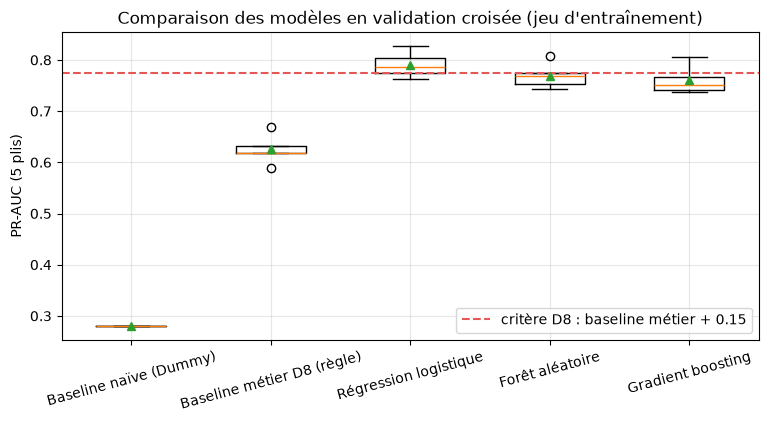

In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

candidats = {
    "Régression logistique": pipeline_modele(LogisticRegression(max_iter=3000)),
    "Forêt aléatoire": pipeline_modele(
        RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
        standardiser=False),
    "Gradient boosting": pipeline_modele(
        HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, random_state=RANDOM_STATE),
        standardiser=False),
}
for nom, pipe in candidats.items():
    resultats_cv.append(evaluer_cv(nom, pipe))

comparaison = pd.DataFrame(resultats_cv)
seuil_d8_cv = comparaison.set_index("modèle").loc["Baseline métier D8 (règle)", "pr_auc"] + GAIN_MIN_D8
display(comparaison.drop(columns="plis").round(3))

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(comparaison["plis"], tick_labels=comparaison["modèle"], showmeans=True)
ax.axhline(seuil_d8_cv, linestyle="--", color=COULEURS["churn"], label=f"critère D8 : baseline métier + {GAIN_MIN_D8}")
ax.set_ylabel("PR-AUC (5 plis)")
ax.set_title("Comparaison des modèles en validation croisée (jeu d'entraînement)")
ax.tick_params(axis="x", rotation=15)
ax.legend(loc="lower right")
sauver_figure(fig, "07_comparaison_modeles_cv")
plt.show()

### 8.4 Le Gold v2 est-il justifié ? Étude d'ablation

Une **étude d'ablation** retire ou ajoute un groupe de variables et mesure l'effet sur la
performance. Elle répond à trois questions : retirer les leurres et les redondances coûte-t-il
quelque chose ? Les idées de variables supplémentaires (indicateurs de manquants, nouveaux
ratios) apportent-elles quelque chose ? Garder `sieges_souscrits` est-il neutre ?

📘 **Explication — l'ablation**

On compare six jeux de variables avec **le même modèle** (régression logistique) et **la même
validation croisée** : seule la liste de variables change, donc toute différence vient d'elle.

- *v1 (30 variables)* reconstruit le jeu de la version précédente : leurres et colonnes du
  catalogue compris (`support_dedie` est alors une catégorielle Oui/Non).
- Les cinq ratios candidats sont calculés à la volée sur le jeu d'entraînement.

Lecture attendue : si deux jeux ont des scores dont l'écart est bien inférieur à l'écart-type,
ils sont équivalents ; on préfère alors **le plus simple**.

In [22]:
v1_features = json.loads((GOLD_DIR / "gold_manifest.json").read_text(encoding="utf-8"))["features_modele_principal"]
v1_categorielles = [c for c in v1_features if c in
                    ["secteur", "pays", "taille_entreprise", "plan", "jour_souscription",
                     "couleur_theme_interface", "code_datacenter", "groupe_experimentation", "support_dedie"]]
silver_train = silver[silver["split"] == "train"].reset_index(drop=True)
assert (silver_train["client_id"] == train["client_id"]).all()   # mêmes comptes, même ordre

# Ratios candidats (non retenus si sans gain)
actifs = silver_train["utilisateurs_actifs"].clip(lower=1)
ratios = pd.DataFrame({
    "sieges_inutilises_pct": 1 - silver_train["utilisateurs_actifs"] / silver_train["sieges_souscrits"].clip(lower=1),
    "connexions_par_actif": silver_train["connexions_30j"] / actifs,
    "heures_par_actif": silver_train["heures_usage_30j"] / actifs,
    "tickets_par_actif": silver_train["tickets_support_90j"] / actifs,
    "remise_vs_catalogue": silver_train["revenu_mensuel_recurrent_eur"]
                           / (silver_train["sieges_souscrits"] * silver_train["prix_mensuel_par_siege_eur"]),
})
X_train_etendu = pd.concat([silver_train[[c for c in v1_features if c not in FEATURES_V2]],  # colonnes v1 seulement
                            X_train, ratios], axis=1)
sans_leurres_v1 = [c for c in v1_features if c not in LEURRES]
sans_sieges = [c for c in NUMERIQUES_V2 if c != "sieges_souscrits"]
lr = LogisticRegression(max_iter=3000)

variantes = [
    ("v1 : 30 variables (leurres + catalogue)",
     pipeline_modele(lr, v1_categorielles, [c for c in v1_features if c not in v1_categorielles]), v1_features),
    ("v1 sans les 5 leurres (25)",
     pipeline_modele(lr, [c for c in v1_categorielles if c not in LEURRES],
                     [c for c in sans_leurres_v1 if c not in v1_categorielles]), sans_leurres_v1),
    ("v2 : 20 variables (retenue)", pipeline_modele(lr), FEATURES_V2),
    ("v2 + indicateurs de manquants", pipeline_modele(lr, indicateurs=True), FEATURES_V2),
    ("v2 + 5 ratios candidats", pipeline_modele(lr, CATEGORIELLES_V2, NUMERIQUES_V2 + list(ratios.columns)),
     FEATURES_V2 + list(ratios.columns)),
    ("v2 sans sieges_souscrits", pipeline_modele(lr, CATEGORIELLES_V2, sans_sieges), CATEGORIELLES_V2 + sans_sieges),
]
ablation = pd.DataFrame([{**evaluer_cv(nom, pipe, X_train_etendu[cols]), "nb_variables": len(cols)}
                         for nom, pipe, cols in variantes]).drop(columns="plis")
display(ablation[["modèle", "nb_variables", "pr_auc", "pr_auc_std", "roc_auc"]].round(4))

,modèle,nb_variables,pr_auc,pr_auc_std,roc_auc
0,v1 : 30 variables (leurres + catalogue),30,0.7869,0.0218,0.8880
1,v1 sans les 5 leurres (25),25,0.7904,0.0224,0.8898
2,v2 : 20 variables (retenue),20,0.7906,0.0224,0.8899
3,v2 + indicateurs de manquants,20,0.7894,0.0227,0.8891
4,v2 + 5 ratios candidats,25,0.7893,0.0225,0.8894
5,v2 sans sieges_souscrits,19,0.7906,0.0221,0.8900


📘 **Explication — appliquer la règle de sélection**

La règle, fixée **avant** de regarder les résultats (§8.1) : on prend le modèle au meilleur
score moyen ; tout modèle dont l'écart avec le meilleur est inférieur à un écart-type est
considéré à égalité, et on retient alors le plus simple et le plus explicable (ordre de
préférence : régression logistique, puis gradient boosting, puis forêt aléatoire).

La cellule applique cette règle automatiquement, puis vérifie le critère D8.

In [23]:
modeles_ml = comparaison[comparaison["modèle"].isin(candidats)].set_index("modèle")
meilleur = modeles_ml["pr_auc"].idxmax()
a_egalite = modeles_ml.index[modeles_ml["pr_auc"] >= modeles_ml.loc[meilleur, "pr_auc"] - modeles_ml.loc[meilleur, "pr_auc_std"]]
ordre_simplicite = ["Régression logistique", "Gradient boosting", "Forêt aléatoire"]
MODELE_RETENU = next(m for m in ordre_simplicite if m in a_egalite)

print(f"Meilleur score moyen : {meilleur} ({modeles_ml.loc[meilleur, 'pr_auc']:.3f} ± {modeles_ml.loc[meilleur, 'pr_auc_std']:.3f})")
print(f"Modèles à égalité (écart < 1 écart-type) : {list(a_egalite)}")
print(f"Modèle retenu : {MODELE_RETENU}")
print(f"Critère D8 en CV : {modeles_ml.loc[MODELE_RETENU, 'pr_auc']:.3f} >= {seuil_d8_cv:.3f} ? "
      f"{modeles_ml.loc[MODELE_RETENU, 'pr_auc'] >= seuil_d8_cv}")

Meilleur score moyen : Régression logistique (0.791 ± 0.022)
Modèles à égalité (écart < 1 écart-type) : ['Régression logistique', 'Forêt aléatoire']
Modèle retenu : Régression logistique
Critère D8 en CV : 0.791 >= 0.775 ? True


**Lecture.**

- Les trois familles dépassent largement la baseline naïve et la baseline métier.
- La **régression logistique** obtient le meilleur score moyen, devant le gradient boosting et
  la forêt aléatoire. Les modèles plus complexes n'apportent rien : la relation entre les
  signaux d'engagement et le churn est essentiellement **linéaire** (au sens du logit). C'est
  une bonne nouvelle : le modèle le plus simple est aussi le plus performant et le plus
  explicable.
- **Ablation** : retirer les 5 leurres et les 5 colonnes redondantes ne coûte rien (30 → 20
  variables pour un score identique). Les indicateurs de manquants et les ratios candidats
  n'apportent rien : ils ne sont pas retenus. Retirer `sieges_souscrits` est neutre pour le
  churn : la garder ne dégrade rien et sert la régression CLV.

### 📓 Journal de bord — §8 Choix du modèle [C4]

- **Protocole** : validation croisée stratifiée 5 plis sur le seul train ; test fermé.
- **Baselines** : naïve (PR-AUC ≈ taux de base) et **métier D8** reformulée sans la variable de
  fuite (ancienneté, intégrations, récence de connexion).
- **Trois familles** comparées : linéaire, bagging, boosting. La régression logistique est la
  meilleure ; les modèles plus complexes n'apportent rien sur ces données.
- **Règle de sélection fixée à l'avance** et appliquée par le code (pas de choix a posteriori
  sur le jeu de test, **correction d'un défaut de la v1** qui choisissait le modèle sur le test).
- **Ablation** : le Gold v2 (20 variables) fait aussi bien que la v1 (30 variables) ; il est plus
  simple, conforme à l'énoncé (leurres exclus) et plus lisible.
- **D8 respecté** en validation croisée (vérifié à nouveau sur le test en §9).

## 9. Entraînement, validation et ajustement — journal de bord [C5]

### 9.1 Réglage de la régularisation

📘 **Explication — régler l'hyperparamètre C**

La régression logistique a un **hyperparamètre de régularisation** `C` : plus `C` est petit,
plus le modèle est contraint à garder des coefficients faibles (il « simplifie » pour éviter de
coller au bruit des données, le **surapprentissage**) ; plus `C` est grand, plus il est libre.

`GridSearchCV` essaie plusieurs valeurs de `C` et mesure chacune en validation croisée, toujours
sur le seul jeu d'entraînement. Il réentraîne ensuite automatiquement le meilleur modèle sur
**tout** le jeu d'entraînement (`refit=True`).

Le graphique montre le score moyen ± un écart-type pour chaque valeur : une courbe plate
signifie que le choix de `C` compte peu, ce qui est un signe de robustesse.

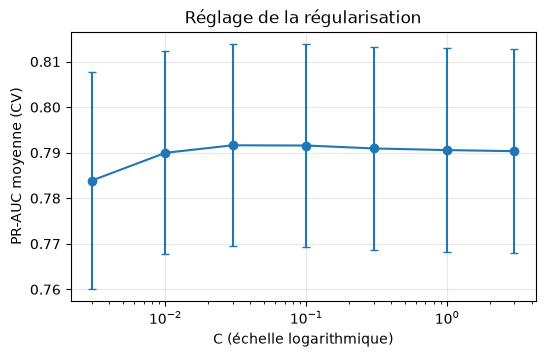

C retenu : 0.03 | PR-AUC CV : 0.7916


In [24]:
from sklearn.model_selection import GridSearchCV

grille = GridSearchCV(pipeline_modele(LogisticRegression(max_iter=3000)),
                      param_grid={"modele__C": [0.003, 0.01, 0.03, 0.1, 0.3, 1, 3]},
                      scoring="average_precision", cv=cv, refit=True)
grille.fit(X_train, y_train)
resultats_grille = pd.DataFrame(grille.cv_results_)[["param_modele__C", "mean_test_score", "std_test_score"]]
C_RETENU = grille.best_params_["modele__C"]
modele_churn = grille.best_estimator_

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.errorbar(resultats_grille["param_modele__C"].astype(float), resultats_grille["mean_test_score"],
            yerr=resultats_grille["std_test_score"], marker="o", capsize=3)
ax.set_xscale("log")
ax.set_xlabel("C (échelle logarithmique)")
ax.set_ylabel("PR-AUC moyenne (CV)")
ax.set_title("Réglage de la régularisation")
sauver_figure(fig, "08_reglage_C")
plt.show()
print(f"C retenu : {C_RETENU} | PR-AUC CV : {grille.best_score_:.4f}")

### 9.2 Choix du seuil de décision (D9) sans toucher au test

Un modèle de classification produit une **probabilité**. Pour décider quels comptes signaler, il
faut un **seuil** : au-dessus, le compte est signalé. Le seuil par défaut de 0,5 n'a aucune
justification métier. D9 impose : le seuil doit garantir un **rappel ≥ 80 %** (au moins 8 comptes
sur 10 qui vont partir doivent être signalés).

**Correction par rapport à la v1** : la v1 calculait ce seuil sur le jeu de test, ce qui garantit
80 % de rappel sur le test *par construction* et rend la mesure optimiste. Ici, le seuil est
calculé sur des **prédictions hors pli** du jeu d'entraînement ; le rappel mesuré ensuite sur le
test est une estimation honnête de ce que l'on obtiendra en production.

📘 **Explication — prédictions hors pli et calibration du seuil**

`cross_val_predict` produit, pour chaque compte du jeu d'entraînement, une probabilité calculée
par un modèle qui **n'a pas vu ce compte** pendant son entraînement (il a été entraîné sur les 4
autres plis). Ces prédictions « hors pli » (*out-of-fold*) se comportent comme des prédictions
sur des données nouvelles.

`calibrer_seuil_d9` (module `src/scoring.py`) cherche ensuite **le seuil le plus élevé** qui
respecte encore un rappel de 80 %. Pourquoi le plus élevé ? Parce qu'un seuil plus haut signale
moins de comptes, donc moins de faux positifs : c'est la meilleure précision possible sous la
contrainte de rappel.

In [25]:
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import cross_val_predict
from src.scoring import calibrer_seuil_d9

proba_oof = cross_val_predict(clone(modele_churn), X_train, y_train, cv=cv, method="predict_proba")[:, 1]
SEUIL_D9 = calibrer_seuil_d9(y_train, proba_oof, rappel_cible=RAPPEL_CIBLE_D9)
signales_oof = proba_oof >= SEUIL_D9
print(f"Seuil D9 (calculé hors pli, sur le train) : {SEUIL_D9:.3f}")
print(f"  rappel hors pli    : {recall_score(y_train, signales_oof):.3f}")
print(f"  précision hors pli : {precision_score(y_train, signales_oof):.3f}")
print(f"  comptes signalés   : {signales_oof.mean():.1%}")

Seuil D9 (calculé hors pli, sur le train) : 0.286
  rappel hors pli    : 0.800
  précision hors pli : 0.614
  comptes signalés   : 36.5%


### 9.3 Évaluation finale sur le jeu de test (utilisé une seule fois)

📘 **Explication — l'évaluation finale**

C'est **la seule fois** que le jeu de test est utilisé. Le modèle, son hyperparamètre `C` et son
seuil sont figés ; on mesure :

- la **ROC-AUC** : probabilité qu'un compte qui part reçoive un score plus élevé qu'un compte qui
  reste (0,5 = hasard, 1 = parfait) ;
- la **PR-AUC** : qualité du compromis précision/rappel, à comparer au taux de base (0,28) ;
- au **seuil D9** : le **rappel** (part des comptes qui partent effectivement signalés) et la
  **précision** (part des comptes signalés qui partent effectivement) ;
- le **critère D8** : écart de PR-AUC avec la baseline métier, sur le test cette fois.

In [26]:
proba_test = modele_churn.predict_proba(X_test)[:, 1]
score_regle_test = score_regle_metier(X_test, X_train["nb_integrations"].median())

metriques_test = {
    "roc_auc": roc_auc_score(y_test, proba_test),
    "pr_auc": average_precision_score(y_test, proba_test),
    "pr_auc_baseline_naive": float(y_test.mean()),
    "pr_auc_baseline_metier_D8": average_precision_score(y_test, score_regle_test),
    "roc_auc_baseline_metier_D8": roc_auc_score(y_test, score_regle_test),
    "rappel_seuil_D9": recall_score(y_test, proba_test >= SEUIL_D9),
    "precision_seuil_D9": precision_score(y_test, proba_test >= SEUIL_D9),
    "part_signales_seuil_D9": float((proba_test >= SEUIL_D9).mean()),
    "rappel_seuil_0_5": recall_score(y_test, proba_test >= 0.5),
    "precision_seuil_0_5": precision_score(y_test, proba_test >= 0.5),
}
metriques_test["gain_pr_auc_vs_D8"] = metriques_test["pr_auc"] - metriques_test["pr_auc_baseline_metier_D8"]
metriques_test["critere_D8_respecte"] = bool(metriques_test["gain_pr_auc_vs_D8"] >= GAIN_MIN_D8)
display(pd.Series(metriques_test, name="jeu de test").to_frame().T.round(3).T)

,jeu de test
roc_auc,0.882659
pr_auc,0.760979
pr_auc_baseline_naive,0.28
pr_auc_baseline_metier_D8,0.593084
roc_auc_baseline_metier_D8,0.791307
rappel_seuil_D9,0.807143
precision_seuil_D9,0.624309
part_signales_seuil_D9,0.362
rappel_seuil_0_5,0.567857
precision_seuil_0_5,0.716216


📘 **Explication — courbes ROC et précision-rappel**

- **Courbe ROC** : pour chaque seuil possible, le taux de vrais positifs (rappel) en fonction du
  taux de faux positifs. Plus la courbe est proche du coin supérieur gauche, meilleur est le
  modèle ; la diagonale correspond au hasard.
- **Courbe précision-rappel** : pour chaque seuil, la précision en fonction du rappel. La ligne
  horizontale est le taux de base (ce que donnerait un tirage au hasard). Le point marque le
  **seuil D9** retenu : on y lit directement le compromis choisi.

La baseline métier D8 est tracée en pointillés pour visualiser l'apport du modèle.

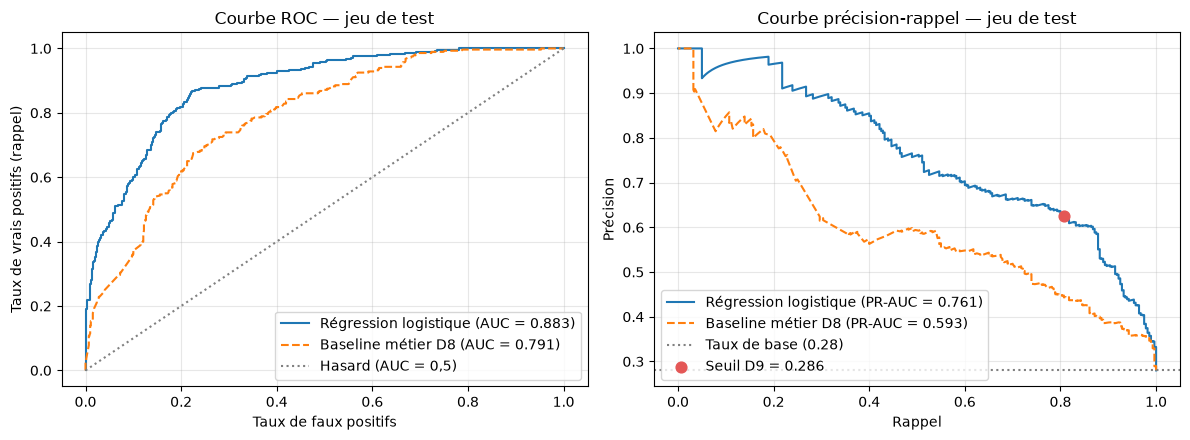

In [27]:
from sklearn.metrics import precision_recall_curve, roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for nom, score, style in [("Régression logistique", proba_test, "-"), ("Baseline métier D8", score_regle_test, "--")]:
    fpr, tpr, _ = roc_curve(y_test, score)
    ax1.plot(fpr, tpr, style, label=f"{nom} (AUC = {roc_auc_score(y_test, score):.3f})")
    prec, rapp, _ = precision_recall_curve(y_test, score)
    ax2.plot(rapp, prec, style, label=f"{nom} (PR-AUC = {average_precision_score(y_test, score):.3f})")
ax1.plot([0, 1], [0, 1], ":", color="gray", label="Hasard (AUC = 0,5)")
ax1.set_xlabel("Taux de faux positifs")
ax1.set_ylabel("Taux de vrais positifs (rappel)")
ax1.set_title("Courbe ROC — jeu de test")
ax1.legend(loc="lower right")
ax2.axhline(y_test.mean(), linestyle=":", color="gray", label=f"Taux de base ({y_test.mean():.2f})")
ax2.scatter([metriques_test["rappel_seuil_D9"]], [metriques_test["precision_seuil_D9"]], color=COULEURS["churn"],
            zorder=5, s=60, label=f"Seuil D9 = {SEUIL_D9:.3f}")
ax2.set_xlabel("Rappel")
ax2.set_ylabel("Précision")
ax2.set_title("Courbe précision-rappel — jeu de test")
ax2.legend(loc="lower left")
fig.tight_layout()
sauver_figure(fig, "09_courbes_roc_pr")
plt.show()

📘 **Explication — matrices de confusion**

Une matrice de confusion compte les quatre situations possibles :

| | prédit « reste » | prédit « résilie » |
|---|---|---|
| **reste réellement** | vrai négatif | **faux positif** (relance inutile) |
| **résilie réellement** | **faux négatif** (compte perdu sans alerte) | vrai positif |

On compare le seuil par défaut (0,5) au seuil D9 : on doit voir les faux négatifs diminuer
fortement, au prix de davantage de faux positifs. C'est exactement l'arbitrage voulu par D4.

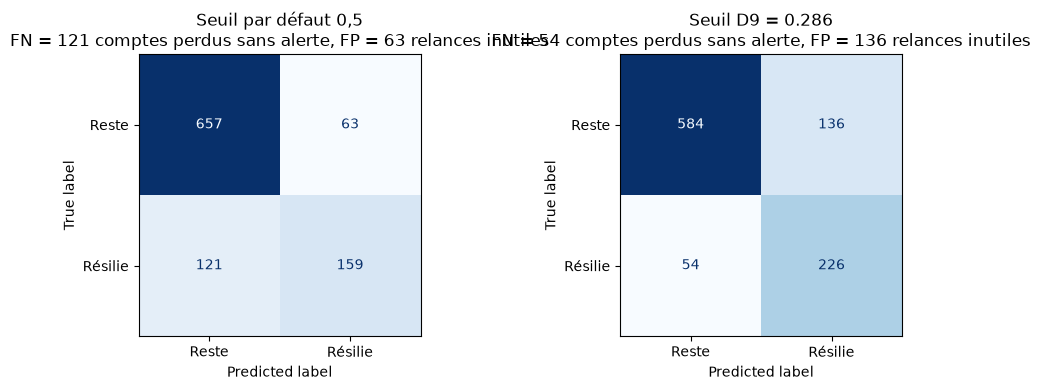

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, seuil, titre in [(axes[0], 0.5, "Seuil par défaut 0,5"), (axes[1], SEUIL_D9, f"Seuil D9 = {SEUIL_D9:.3f}")]:
    matrice = confusion_matrix(y_test, proba_test >= seuil)
    ConfusionMatrixDisplay(matrice, display_labels=["Reste", "Résilie"]).plot(ax=ax, cmap="Blues", colorbar=False)
    tn, fp, fn, tp = matrice.ravel()
    ax.set_title(f"{titre}\nFN = {fn} comptes perdus sans alerte, FP = {fp} relances inutiles")
    ax.grid(False)
fig.tight_layout()
sauver_figure(fig, "10_matrices_confusion")
plt.show()

**Lecture.** Au seuil D9, le rappel mesuré sur le test est proche de la cible de 80 % fixée sur
le train : le seuil se **généralise**. Le nombre de faux négatifs diminue fortement par rapport
au seuil de 0,5, au prix de faux positifs supplémentaires, ce qui est l'arbitrage voulu (D4).
Le critère D8 est respecté sur le test : le modèle apporte une valeur nette par rapport à une
règle métier simple.

### 9.4 Les probabilités sont-elles fiables ? Calibration

📘 **Explication — calibration des probabilités**

La priorisation (D14) multiplie la probabilité de churn par la CLV estimée pour obtenir une
**perte attendue en euros**. Ce calcul n'a de sens que si les probabilités sont **calibrées** :
parmi les comptes à qui le modèle donne 30 %, environ 30 % doivent effectivement partir.

- La **courbe de calibration** range les comptes du test en 10 groupes de probabilité prédite et
  compare, pour chaque groupe, la probabilité moyenne prédite au taux de churn observé. Un
  modèle parfaitement calibré suit la diagonale.
- Le **score de Brier** est l'erreur quadratique moyenne entre probabilité et issue réelle (0 =
  parfait). On le compare à celui d'un modèle qui prédirait toujours le taux de base.

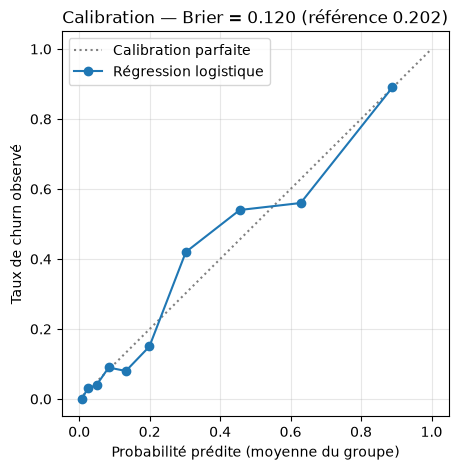

Probabilité moyenne prédite : 0.277 | taux de churn réel : 0.280


In [29]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_observee, prob_predite = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, proba_test)
brier_reference = brier_score_loss(y_test, np.full_like(proba_test, y_train.mean()))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ":", color="gray", label="Calibration parfaite")
ax.plot(prob_predite, prob_observee, "o-", label="Régression logistique")
ax.set_xlabel("Probabilité prédite (moyenne du groupe)")
ax.set_ylabel("Taux de churn observé")
ax.set_title(f"Calibration — Brier = {brier:.3f} (référence {brier_reference:.3f})")
ax.legend()
sauver_figure(fig, "11_calibration")
plt.show()
print(f"Probabilité moyenne prédite : {proba_test.mean():.3f} | taux de churn réel : {y_test.mean():.3f}")

**Lecture.** La courbe suit la diagonale et le score de Brier est bien inférieur à la référence :
les probabilités sont fiables. Le calcul `perte attendue = p(churn) × CLV` est donc légitime.
C'est un avantage de la régression logistique, dont les probabilités sont naturellement bien
calibrées (les forêts aléatoires, par exemple, le sont souvent moins).

### 9.5 Seuil et coût métier : pourquoi D9 plutôt qu'une minimisation du coût

📘 **Explication — analyse de coût**

Pour chaque seuil possible, on calcule sur les prédictions hors pli du train :

`coût = nombre de faux négatifs × 6 879 € + nombre de faux positifs × coût d'une relance`

avec les deux bornes de l'hypothèse H01 (50 € et 150 €). On repère le seuil qui minimise ce
coût, et la part de comptes qu'il faudrait alors contacter.

Cette analyse montre pourquoi on ne retient pas le seuil de coût minimal : avec un faux négatif
46 à 137 fois plus cher qu'un faux positif, il faudrait contacter la majorité des comptes, bien
au-delà de la capacité de l'équipe (D10). D9 fixe donc un objectif de rappel atteignable, et
D10/D14 gèrent la capacité.

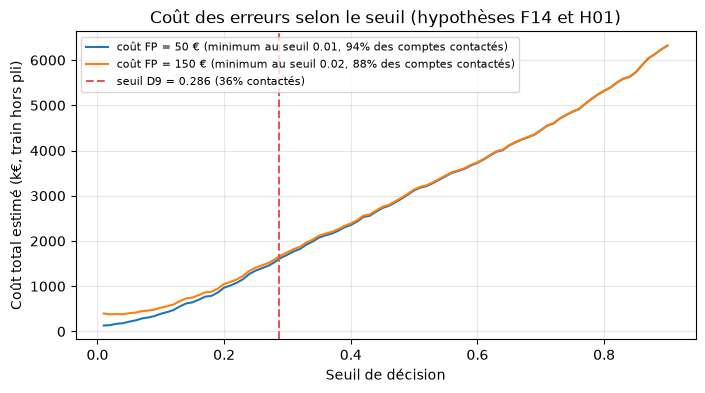

In [30]:
seuils = np.linspace(0.01, 0.9, 90)
fig, ax = plt.subplots(figsize=(8, 4))
for cout_fp in COUTS_FP_EUR:
    couts = [(((proba_oof < s) & (y_train == 1)).sum() * COUT_FN_EUR
              + ((proba_oof >= s) & (y_train == 0)).sum() * cout_fp) / 1e3 for s in seuils]
    s_min = seuils[int(np.argmin(couts))]
    ax.plot(seuils, couts, label=f"coût FP = {cout_fp} € (minimum au seuil {s_min:.2f}, "
                                 f"{(proba_oof >= s_min).mean():.0%} des comptes contactés)")
ax.axvline(SEUIL_D9, color=COULEURS["churn"], linestyle="--", label=f"seuil D9 = {SEUIL_D9:.3f} ({signales_oof.mean():.0%} contactés)")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Coût total estimé (k€, train hors pli)")
ax.set_title("Coût des erreurs selon le seuil (hypothèses F14 et H01)")
ax.legend(fontsize=8)
sauver_figure(fig, "12_cout_seuil")
plt.show()

### 9.6 Explicabilité : quels facteurs pèsent sur le risque ?

📘 **Explication — deux lectures complémentaires**

1. **Coefficients de la régression logistique.** Les variables numériques étant standardisées,
   un coefficient se lit ainsi : « quand la variable augmente d'un écart-type, le logarithme du
   rapport de chances de churn augmente de ce coefficient ». Positif = augmente le risque,
   négatif = le diminue. C'est l'explication que l'on peut donner à un CSM.
2. **Importance par permutation** (sur le test). Pour chaque variable, on mélange aléatoirement
   ses valeurs (ce qui casse son lien avec la cible) et on mesure la baisse de PR-AUC. Une
   forte baisse signifie que le modèle s'appuie vraiment sur cette variable. Cette méthode est
   indépendante du type de modèle. On répète le mélange 20 fois pour obtenir une moyenne et un
   écart-type.

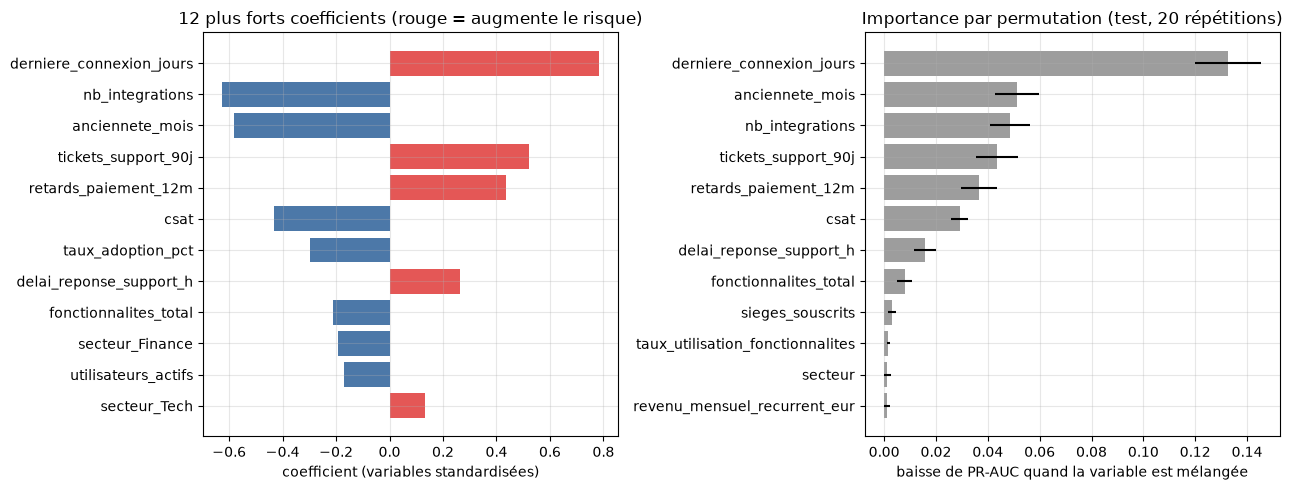

,variable,baisse_pr_auc,ecart_type
0,derniere_connexion_jours,0.1327,0.0127
1,anciennete_mois,0.0513,0.0084
2,nb_integrations,0.0487,0.0076
3,tickets_support_90j,0.0435,0.0082
4,retards_paiement_12m,0.0368,0.0069
5,csat,0.0292,0.0032
6,delai_reponse_support_h,0.0157,0.0044
7,fonctionnalites_total,0.0080,0.0029


In [31]:
from sklearn.inspection import permutation_importance

noms = [n.split("__", 1)[1] for n in modele_churn.named_steps["preparation"].get_feature_names_out()]
coefs = pd.Series(modele_churn.named_steps["modele"].coef_[0], index=noms)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)[::-1]

perm = permutation_importance(modele_churn, X_test, y_test, scoring="average_precision",
                              n_repeats=20, random_state=RANDOM_STATE)
importance = (pd.DataFrame({"variable": FEATURES_V2, "baisse_pr_auc": perm.importances_mean,
                            "ecart_type": perm.importances_std})
              .sort_values("baisse_pr_auc", ascending=False).reset_index(drop=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.barh(top_coefs.index, top_coefs.values,
         color=[COULEURS["churn"] if v > 0 else COULEURS["non_churn"] for v in top_coefs.values])
ax1.set_title("12 plus forts coefficients (rouge = augmente le risque)")
ax1.set_xlabel("coefficient (variables standardisées)")
top_perm = importance.head(12)[::-1]
ax2.barh(top_perm["variable"], top_perm["baisse_pr_auc"], xerr=top_perm["ecart_type"], color=COULEURS["neutre"])
ax2.set_title("Importance par permutation (test, 20 répétitions)")
ax2.set_xlabel("baisse de PR-AUC quand la variable est mélangée")
fig.tight_layout()
sauver_figure(fig, "13_explicabilite")
plt.show()
display(importance.head(8).round(4))

📘 **Explication — les leurres n'apportaient rien : preuve sur le modèle v1**

Pour ne pas sur-interpréter les leurres, on vérifie leur rôle réel dans le **modèle v1**, qui
les contenait encore. On recharge ce modèle, on calcule l'importance par permutation de ses 30
variables sur le même jeu de test, et on regarde le rang des leurres : s'ils sont en bas du
classement avec une importance proche de zéro, les exclure était justifié.

In [32]:
modele_v1 = joblib.load(MODEL_V1_DIR / "model.joblib")
features_v1_modele = json.loads((MODEL_V1_DIR / "model_manifest.json").read_text(encoding="utf-8"))["features"]
test_v1 = pd.read_parquet(GOLD_DIR / "clients_churn_gold.parquet").query("split == 'test'")
perm_v1 = permutation_importance(modele_v1, test_v1[features_v1_modele], test_v1["churn"],
                                 scoring="average_precision", n_repeats=10, random_state=RANDOM_STATE)
rang_v1 = (pd.DataFrame({"variable": features_v1_modele, "baisse_pr_auc": perm_v1.importances_mean})
           .sort_values("baisse_pr_auc", ascending=False).reset_index(drop=True))
rang_v1["rang"] = rang_v1.index + 1
display(rang_v1[rang_v1["variable"].isin(LEURRES)].round(4))
print(f"Rang moyen des leurres dans le modèle v1 : {rang_v1.loc[rang_v1['variable'].isin(LEURRES), 'rang'].mean():.1f} sur {len(rang_v1)}")

,variable,baisse_pr_auc,rang
10,pays,0.0016,11
18,groupe_experimentation,0.0001,19
23,code_datacenter,-0.0010,24
27,jour_souscription,-0.0023,28
28,couleur_theme_interface,-0.0031,29


Rang moyen des leurres dans le modèle v1 : 22.2 sur 30


**Lecture.** Les facteurs de risque sont cohérents avec l'analyse exploratoire et avec
l'intuition métier : récence de connexion, ancienneté, nombre d'intégrations, tickets de
support, retards de paiement et satisfaction. Dans le modèle v1, quatre leurres sur cinq se
classaient entre le 19ᵉ et le 29ᵉ rang sur 30, avec une importance nulle ou négative (le
mélange ne dégrade rien) ; `pays` arrivait au 11ᵉ rang, mais avec une baisse de PR-AUC
négligeable (≈ 0,002). Leur exclusion ne retire aucun signal utile, ce que confirme l'ablation
du §8.4. **Prudence
d'interprétation** : ces lectures décrivent des associations apprises par le modèle, pas des
causes. On ne peut pas conclure qu'ajouter une intégration à un compte réduirait son risque.

### 9.7 Cible secondaire : régression de la valeur vie client

📘 **Explication — modéliser la CLV**

La CLV varie de 300 € à 2 M€ : sa distribution est très étirée vers les grandes valeurs. On
modélise donc `log(1 + CLV)` : le logarithme ramène les écarts à une échelle comparable, et le
modèle n'est plus dominé par quelques très gros comptes. Les prédictions sont retransformées en
euros (`exp(x) − 1`) avant tout calcul métier.

Mêmes règles que pour le churn : mêmes 20 variables (ni `churn`, ni la variable de fuite),
validation croisée à 5 plis sur le train, baseline (médiane), puis trois modèles. Le
coefficient de détermination **R²** mesure la part de la variance expliquée (1 = parfait, 0 =
pas mieux que la moyenne).

La cellule mesure aussi la **taille sur disque** des modèles à base d'arbres : c'est une
contrainte d'exploitation (§11) : un modèle de 60 Mo alourdit l'image Docker et son chargement.

In [33]:
import io

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

y_clv_train = np.log1p(train["valeur_vie_client_eur"])
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
candidats_clv = {
    "Baseline (médiane)": pipeline_modele(DummyRegressor(strategy="median")),
    "Ridge": pipeline_modele(Ridge(alpha=1.0)),
    "Forêt aléatoire": pipeline_modele(RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                                             random_state=RANDOM_STATE, n_jobs=-1), standardiser=False),
    "Gradient boosting": pipeline_modele(HistGradientBoostingRegressor(learning_rate=0.05, max_iter=400,
                                                                       random_state=RANDOM_STATE), standardiser=False),
}
lignes = []
for nom, pipe in candidats_clv.items():
    res = cross_validate(pipe, X_train, y_clv_train, cv=cv_reg, scoring=["r2", "neg_mean_absolute_error"])
    taille = np.nan
    if nom in ("Forêt aléatoire", "Gradient boosting"):
        tampon = io.BytesIO()
        joblib.dump(clone(pipe).fit(X_train, y_clv_train), tampon)
        taille = len(tampon.getvalue()) / 1e6
    lignes.append({"modèle": nom, "r2_log": res["test_r2"].mean(), "r2_log_std": res["test_r2"].std(),
                   "mae_log": -res["test_neg_mean_absolute_error"].mean(), "taille_mo": taille})
comparaison_clv = pd.DataFrame(lignes).set_index("modèle")
display(comparaison_clv.round(3))

meilleur_clv = comparaison_clv["r2_log"].idxmax()
egalite_clv = comparaison_clv[comparaison_clv["r2_log"] >= comparaison_clv.loc[meilleur_clv, "r2_log"]
                              - comparaison_clv.loc[meilleur_clv, "r2_log_std"]]
MODELE_CLV_RETENU = egalite_clv["taille_mo"].fillna(0).idxmin() if len(egalite_clv) > 1 else meilleur_clv
print(f"Meilleur R² moyen : {meilleur_clv} ; à égalité : {list(egalite_clv.index)}")
print(f"Modèle CLV retenu : {MODELE_CLV_RETENU} (à performance égale, le plus léger à exploiter)")
modele_clv = clone(candidats_clv[MODELE_CLV_RETENU]).fit(X_train, y_clv_train)

,r2_log,r2_log_std,mae_log,taille_mo
modèle,,,,
Baseline (médiane),-0.000,0.000,1.640,NaN
Ridge,0.806,0.015,0.708,NaN
Forêt aléatoire,0.887,0.008,0.536,62.546
Gradient boosting,0.883,0.009,0.545,1.467


Meilleur R² moyen : Forêt aléatoire ; à égalité : ['Forêt aléatoire', 'Gradient boosting']
Modèle CLV retenu : Gradient boosting (à performance égale, le plus léger à exploiter)


**Lecture.** La forêt aléatoire et le gradient boosting sont à égalité (écart inférieur à un
écart-type), loin devant Ridge et la baseline. À performance égale, je retiens le **gradient
boosting**, environ 40 fois plus léger sur disque que la forêt : un critère d'exploitation
légitime (taille de l'image Docker, temps de chargement de l'API). La performance en euros sur
le test est présentée en §12.

### 📓 Journal de bord — §9 Entraînement, validation, ajustement [C5]

- **Régularisation** réglée par recherche sur grille en validation croisée ; la courbe est
  plate autour de l'optimum : le modèle est robuste au choix de `C`.
- **Seuil D9 calculé hors pli sur le train**, puis vérifié sur le test : le rappel obtenu sur le
  test est proche de la cible de 80 %. **Correction d'un défaut de la v1**, qui calibrait le
  seuil sur le test.
- **Évaluation unique sur le test** : ROC-AUC, PR-AUC, matrices de confusion, critère D8
  respecté.
- **Calibration vérifiée** (courbe et score de Brier) : les probabilités sont fiables, ce qui
  légitime la perte attendue en euros.
- **Analyse de coût** : minimiser le coût seul obligerait à contacter la majorité des comptes,
  incompatible avec la capacité CS : cela justifie D9 + D10.
- **Explicabilité** : coefficients et importance par permutation cohérents avec le métier ;
  leurres confirmés inutiles sur le modèle v1.
- **CLV** : gradient boosting sur `log(1 + CLV)`, retenu à performance égale pour sa légèreté.

## 10. Implémentation et mise en exploitation — journal de bord [C6]

### 10.1 Sérialisation des modèles et de la règle de décision

📘 **Explication — sauvegarder ce qui sera exploité**

**Sérialiser** un modèle, c'est l'enregistrer sur disque pour le réutiliser sans le réentraîner.
On sauvegarde le **pipeline complet** (préparation + modèle) avec `joblib` : en production, on
lui donnera des données brutes au format des 20 features, et il appliquera lui-même
l'imputation, l'encodage et la standardisation apprises à l'entraînement.

On écrit aussi deux **manifestes** JSON, lus par l'API au démarrage :

- `model_manifest.json` : liste ordonnée des features attendues, version et hash du Gold qui a
  servi à l'entraînement, hyperparamètres, métriques ;
- `scoring_manifest.json` : la **règle de décision** (seuil D9, capacité D10, catalogue D11,
  formule D14). Le seuil est figé ici : il n'est jamais recalculé au moment du scoring, où le
  churn réel n'est par définition pas connu.

Les noms de fichiers sont ceux qu'attend l'API (`src/api.py`) : pour mettre ce modèle en
service, il suffit de pointer la variable `MODEL_DIR` de l'API vers `data/model_v2`.

In [34]:
joblib.dump(modele_churn, MODEL_DIR / "model.joblib")
joblib.dump(modele_clv, MODEL_DIR / "model_clv.joblib")

manifeste_modele = {
    "couche": "model", "version": "v2", "processed_at_utc": datetime.now(timezone.utc).isoformat(),
    "commit_git": commit_git(), "gold_version": "v2", "gold_sha256": sha_gold_v2,
    "modele_retenu": MODELE_RETENU, "hyperparametres": {"C": C_RETENU}, "random_state": RANDOM_STATE,
    "features": FEATURES_V2, "cible": "churn",
    "metriques_cv_train": comparaison.drop(columns="plis").set_index("modèle").round(4).to_dict(orient="index"),
    "metriques_test": {k: (round(v, 4) if isinstance(v, float) else v) for k, v in metriques_test.items()},
    "modele_clv": {"modele_retenu": MODELE_CLV_RETENU, "cible": "log1p(valeur_vie_client_eur)"},
}
write_manifest(MODEL_DIR / "model_manifest.json", manifeste_modele)
write_manifest(MODEL_DIR / "metrics.json", {**manifeste_modele["metriques_test"],
                                            "pr_auc_cv": round(float(grille.best_score_), 4),
                                            "seuil_D9": round(float(SEUIL_D9), 4)})   # suivi par dvc metrics

manifeste_scoring = {
    "couche": "model", "sous_etape": "regle_de_decision", "version": "v2",
    "regle_decision": {
        "seuil_D9_valeur": round(float(SEUIL_D9), 4),
        "seuil_D9_calcule_sur": "prédictions hors pli du jeu d'entraînement (jamais le test)",
        "seuil_D9_rappel_cible": RAPPEL_CIBLE_D9,
        "rappel_test": round(metriques_test["rappel_seuil_D9"], 4),
        "precision_test": round(metriques_test["precision_seuil_D9"], 4),
        "capacite_csm_D10": CAPACITE_CSM_D10,
        "formule_priorite_D14": "perte_attendue = score_churn x valeur_vie_estimee_eur",
        "catalogue_actions_D11": ACTIONS_PAR_PRIORITE,
    },
    "colonnes_export_crm": ["client_id", "score_churn", "valeur_vie_estimee_eur", "priorite", "action_recommandee"],
}
write_manifest(MODEL_DIR / "scoring_manifest.json", manifeste_scoring)
print("Fichiers écrits dans", MODEL_DIR.relative_to(ROOT), ":", sorted(p.name for p in MODEL_DIR.glob("*.*")))

Fichiers écrits dans data\model_v2 : ['.gitignore', 'metrics.json', 'mlflow.db', 'model.joblib', 'model_clv.joblib', 'model_manifest.json', 'scoring_manifest.json']


📘 **Explication — vérifier que la sauvegarde est fidèle**

Un test simple mais indispensable : on **recharge** les modèles depuis le disque et on vérifie
qu'ils donnent exactement les mêmes prédictions que les modèles en mémoire. Si ce n'était pas le
cas (version de bibliothèque différente, étape manquante dans le pipeline…), la production ne
reproduirait pas les résultats de ce notebook.

In [35]:
churn_recharge = joblib.load(MODEL_DIR / "model.joblib")
clv_recharge = joblib.load(MODEL_DIR / "model_clv.joblib")
assert np.allclose(churn_recharge.predict_proba(X_test)[:, 1], proba_test)
assert np.allclose(clv_recharge.predict(X_test), modele_clv.predict(X_test))
print("Modèles rechargés : prédictions identiques à celles du notebook.")

Modèles rechargés : prédictions identiques à celles du notebook.


### 10.2 Exemple d'usage : le cycle de scoring mensuel

📘 **Explication — de deux scores à une liste de travail**

On simule un cycle de scoring mensuel sur les 1 000 comptes du jeu de test (comptes jamais vus
par les modèles) :

1. `scorer_batch` calcule pour chaque compte la probabilité de churn, la CLV estimée (en euros)
   et la **perte attendue** = probabilité × CLV ;
2. `assigner_priorites` applique la règle D14 :
   - **Haute** : comptes signalés (probabilité ≥ seuil D9), classés par perte attendue
     décroissante, dans la limite de **150** (capacité D10) ;
   - **Moyenne** : les autres comptes signalés ;
   - **Basse** : les comptes non signalés ;
3. chaque priorité reçoit l'action correspondante du catalogue D11.

On affiche la répartition des priorités et le **Top 10**, c'est-à-dire ce que l'équipe CS verrait
en tête de liste le premier jour du mois. L'export vers le CRM ne contient que 5 colonnes
(minimisation, §4).

In [36]:
from src.scoring import assigner_priorites, scorer_batch

cycle = scorer_batch(X_test, test["client_id"], modele_churn, modele_clv)
cycle = assigner_priorites(cycle, seuil_d9=SEUIL_D9, capacite_haute=CAPACITE_CSM_D10)
print("Répartition des priorités :", cycle["priorite"].value_counts().reindex(["Haute", "Moyenne", "Basse"]).to_dict())
display(cycle.sort_values("perte_attendue_eur", ascending=False)
        .head(10)[["client_id", "score_churn", "valeur_vie_estimee_eur", "perte_attendue_eur", "priorite", "action_recommandee"]])

export_crm = cycle[manifeste_scoring["colonnes_export_crm"]]
export_crm.to_parquet(MODEL_DIR / "scoring_exemple_cycle.parquet", index=False)
assert "commentaire_csm" not in export_crm.columns
assert all(action_est_conforme_d3(a) for a in export_crm["action_recommandee"].unique())
print(f"Export CRM : {export_crm.shape[0]} lignes x {export_crm.shape[1]} colonnes -> scoring_exemple_cycle.parquet")

Répartition des priorités : {'Haute': 150, 'Moyenne': 212, 'Basse': 638}


,client_id,score_churn,valeur_vie_estimee_eur,perte_attendue_eur,priorite,action_recommandee
851,CLI-004433,0.800,510507.0,408562.0,Haute,Appel personnalisé du CSM référent sous 5 jour...
766,CLI-003063,0.800,478430.0,382691.0,Haute,Appel personnalisé du CSM référent sous 5 jour...
561,CLI-002305,0.336,952709.0,320338.0,Haute,Appel personnalisé du CSM référent sous 5 jour...
538,CLI-000778,0.598,481056.0,287824.0,Haute,Appel personnalisé du CSM référent sous 5 jour...
652,CLI-000678,0.446,612398.0,273386.0,Haute,Appel personnalisé du CSM référent sous 5 jour...
211,CLI-002154,0.343,685241.0,235365.0,Haute,Appel personnalisé du CSM référent sous 5 jour...
358,CLI-002470,0.600,382218.0,229314.0,Haute,Appel personnalisé du CSM référent sous 5 jour...
527,CLI-000791,0.887,254289.0,225619.0,Haute,Appel personnalisé du CSM référent sous 5 jour...
267,CLI-001429,0.767,283250.0,217137.0,Haute,Appel personnalisé du CSM référent sous 5 jour...
427,CLI-002050,0.194,1113865.0,216279.0,Basse,"Surveillance passive, sans action dédiée"


Export CRM : 1000 lignes x 5 colonnes -> scoring_exemple_cycle.parquet


**Lecture.** Les 9 premiers comptes par perte attendue sont en priorité Haute. Le 10ᵉ reste
en priorité **Basse** alors que sa perte attendue est élevée : sa probabilité de churn est sous
le seuil D9, mais sa CLV estimée dépasse le million d'euros. C'est une conséquence directe de
D14 (le seuil D9 est la porte d'entrée, la valeur ne fait qu'ordonner les comptes signalés).
Ce choix est assumé, mais il a un coût, mesuré en §12.4.

### 10.3 Scorer un export brut : la même chaîne qu'à l'entraînement

📘 **Explication — éviter l'écart entre entraînement et production**

Un piège classique en production : le modèle a été entraîné sur des données nettoyées par le
notebook, mais on lui envoie en production des données préparées autrement. Les prédictions
deviennent alors fausses sans aucune erreur visible (*training-serving skew*).

Ici, on prend le fichier `churn_saas_echantillon.csv` (50 comptes, **au format brut** d'un export
CRM, avec ses défauts) et on lui applique **exactement les mêmes fonctions** qu'à l'entraînement :
`load_raw` → `clean_silver` → `construire_features_v2`. Les valeurs manquantes restantes sont
laissées au pipeline, qui les impute avec les médianes apprises sur le train.

On montre aussi que le **modèle v1** échouait sur une valeur manquante : il n'avait pas
d'imputation interne. C'est le défaut corrigé par la v2.

In [37]:
brut_echantillon = load_raw(FICHIERS_SOURCES["echantillon"], ingested_at=datetime.now(timezone.utc).isoformat())
silver_echantillon, _ = clean_silver(brut_echantillon, catalogue_brut, impute_medians=False)
X_echantillon = construire_features_v2(silver_echantillon)
print(f"Export brut : {len(brut_echantillon)} comptes -> {X_echantillon.shape[1]} features, "
      f"{int(X_echantillon.isna().sum().sum())} valeurs manquantes laissées au pipeline")

scores_echantillon = scorer_batch(X_echantillon, silver_echantillon["client_id"], modele_churn, modele_clv)
display(scores_echantillon.head(5))

ligne_avec_manquant = test_v1[features_v1_modele].head(1).assign(csat=np.nan)
try:
    modele_v1.predict_proba(ligne_avec_manquant)
    print("Modèle v1 : valeur manquante acceptée")
except ValueError as erreur:
    print(f"Modèle v1 sur une valeur manquante -> ValueError : {str(erreur).splitlines()[0]}")

Export brut : 50 comptes -> 20 features, 16 valeurs manquantes laissées au pipeline


,client_id,score_churn,valeur_vie_estimee_eur,perte_attendue_eur
0,CLI-004593,0.545,1887.0,1029.0
1,CLI-003145,0.417,12046.0,5021.0
2,CLI-003092,0.047,9955.0,471.0
3,CLI-002921,0.011,37439.0,403.0
4,CLI-004313,0.995,18384.0,18287.0


Modèle v1 sur une valeur manquante -> ValueError : Input X contains NaN.


### 10.4 L'API de scoring, testée de bout en bout

📘 **Explication — tester l'API sans serveur**

L'API (`src/api.py`, FastAPI) expose `/health`, `/ready`, `/metrics` et `/score-batch`. Elle est
déployée en conteneur Docker (§11). Ici, on la teste **dans le notebook**, sans démarrer de
serveur, grâce au `TestClient` de FastAPI qui simule des requêtes HTTP.

Les tests :

1. `/health` et `/ready` répondent (le modèle v2 est chargé) ;
2. `/score-batch` sur les 50 comptes de l'export brut renvoie **exactement les mêmes scores**
   que l'appel direct aux modèles (même code, mêmes modèles, aucune divergence) ;
3. **robustesse** : une valeur manquante et un plan inconnu sont acceptés (code 200) ;
4. **sécurité** : une requête sans clé API est refusée (code 401).

In [38]:
from fastapi.testclient import TestClient

os.environ["API_KEY"] = "cle-demo-notebook"
import src.api as api

api.load_artifacts(MODEL_DIR)
client_api = TestClient(api.app)
entete = {"X-API-Key": "cle-demo-notebook"}

print("GET /health ->", client_api.get("/health").json())
print("GET /ready  ->", client_api.get("/ready").json())

lignes_json = json.loads(X_echantillon.to_json(orient="records"))      # NaN -> null
charge = {"clients": [{"client_id": cid, "features": f}
                      for cid, f in zip(silver_echantillon["client_id"], lignes_json)]}
reponse = client_api.post("/score-batch", json=charge, headers=entete)
resultats_api = pd.DataFrame(reponse.json()["resultats"])
ecart = (resultats_api.set_index("client_id")["score_churn"]
         - scores_echantillon.set_index("client_id")["score_churn"]).abs().max()
print(f"POST /score-batch -> {reponse.status_code}, {len(resultats_api)} comptes, "
      f"écart maximal avec l'appel direct : {ecart}")

cas_limites = {
    "valeur manquante (csat = null)": dict(lignes_json[0], csat=None),
    "plan inconnu (Premium)": dict(lignes_json[0], plan="Premium"),
}
for nom, f in cas_limites.items():
    r = client_api.post("/score-batch", json={"clients": [{"client_id": "TEST", "features": f}]}, headers=entete)
    print(f"{nom:32s} -> {r.status_code}, score {r.json()['resultats'][0]['score_churn']}")
r = client_api.post("/score-batch", json=charge)
print(f"{'sans clé API':32s} -> {r.status_code} {r.json()['detail']}")
assert reponse.status_code == 200 and ecart <= 1e-3 and r.status_code == 401

C:\Users\Aelion\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


GET /health -> {'status': 'ok'}
GET /ready  -> {'status': 'ready'}
POST /score-batch -> 200, 50 comptes, écart maximal avec l'appel direct : 0.0
valeur manquante (csat = null)   -> 200, score 0.348
plan inconnu (Premium)           -> 200, score 0.563
sans clé API                     -> 401 Clé API manquante ou invalide


### 📓 Journal de bord — §10 Implémentation [C6]

- **Sérialisation** : pipelines complets (préparation + modèle) enregistrés avec `joblib` ;
  rechargement vérifié (prédictions identiques).
- **Règle de décision figée** dans `scoring_manifest.json` (seuil D9, capacité D10, catalogue
  D11), jamais recalculée au scoring.
- **Exemple d'usage** : cycle mensuel sur 1 000 comptes → 150 priorités Hautes ordonnées par
  perte attendue, export CRM réduit à 5 colonnes, conformité D3 vérifiée.
- **Même chaîne à l'entraînement et en production** : un export brut est préparé par les mêmes
  fonctions (`clean_silver`, `construire_features_v2`) ; plus d'écart possible.
- **Défaut de la v1 corrigé** : l'imputation fait partie du pipeline ; une valeur manquante ne
  fait plus échouer le scoring.
- **API testée de bout en bout** : scores identiques à l'appel direct, robustesse aux manquants
  et aux catégories inconnues, refus sans clé (401).
- **Mise en service** : pointer `MODEL_DIR` de l'API (et de l'image Docker) vers `data/model_v2`.

## 11. Architecture cible et contraintes [C7]

### 11.1 Architecture cible : scoring batch mensuel intégré au CRM

```
 CRM / facturation / support                         Équipe Customer Success
 (export mensuel des comptes)                          (vue CRM : priorité + action)
          │                                                     ▲
          ▼                                                     │ 5 colonnes
 ┌─────────────────┐   ┌──────────────┐   ┌──────────────┐   ┌──┴───────────────┐
 │ 1. Ingestion     │──▶│ 2. Portique   │──▶│ 3. Silver +   │──▶│ 4. Scoring batch  │
 │ Bronze (brut,    │   │ RGPD (GO /    │   │ features v2   │   │ churn + CLV +     │
 │ horodaté, hash)  │   │ NO-GO)        │   │ (src/)        │   │ règle D9/D10/D14  │
 └─────────────────┘   └──────────────┘   └──────────────┘   └──┬───────────────┘
                                                                  │ métriques
          ┌───────────────────────────────────────────────────────┘
          ▼
 ┌─────────────────────────┐   alerte PSI > 0,25    ┌──────────────────────────────┐
 │ 5. Surveillance          │──────────────────────▶│ 6. Ré-entraînement            │
 │ Prometheus + Grafana :   │   rappel < 75 % sur    │ dvc repro → comparaison MLflow │
 │ dérive (PSI), API, volume│   cycle labellisé      │ → promotion si critères OK     │
 └─────────────────────────┘                         └──────────────────────────────┘
   Versioning transverse : Git (code) · DVC + DagsHub (données, modèles) · MLflow (expériences)
```

### 11.2 Correspondance avec ce qui est déjà implémenté

| Brique cible | Implémentation actuelle | Statut |
|---|---|---|
| Ingestion, RGPD, Silver, features | `src/bronze.py`, `notebooks/00`, `src/silver.py`, `src/features.py` | ✅ |
| Scoring + règle de décision | `src/scoring.py`, `data/model_v2/*.json` | ✅ |
| Exposition | API FastAPI en conteneur Docker (clé API, limite de débit, taille de requête) | ✅ |
| Surveillance | Exporteur de dérive + Prometheus + Grafana (`compose.yaml`), alerte PSI | ✅ (sans routage d'alerte) |
| Versioning | Git + GitHub, DVC + DagsHub, MLflow sur DagsHub | ✅ |
| Intégration continue | GitHub Actions : tests, `dvc pull`, build Docker, test de santé | ✅ |
| Orchestration du batch mensuel | — (scoring lancé à la demande) | ⚠️ à ajouter (planificateur type cron / Airflow) |
| Intégration CRM réelle | — (export Parquet d'exemple) | ⚠️ connecteur à développer |

### 11.3 Contraintes

| Contrainte | Exigence | Réponse |
|---|---|---|
| **Volumétrie** | ~5 000 comptes par mois | Scoring en moins d'une seconde (mesuré ci-dessous) : aucune infrastructure distribuée nécessaire |
| **Latence** | Non critique (batch mensuel) | Batch ; l'API sert aussi un scoring à la demande depuis le CRM |
| **Poids des modèles** | Image Docker légère, démarrage rapide | Modèle CLV v2 ≈ 1,5 Mo contre 62 Mo en v1 (mesuré ci-dessous) |
| **Sécurité** | Accès restreint | Clé API, limite de débit, taille de requête bornée, conteneur non-root ; TLS à ajouter derrière un proxy |
| **RGPD** | Minimisation, pas de décision automatisée | Export limité à 5 colonnes, recommandations non exécutoires (D3), clé de pseudonymisation jamais publiée |
| **Explicabilité** | Les CSM doivent comprendre le score | Régression logistique : facteurs de risque lisibles (§9.6) |
| **Reproductibilité** | Rejouer un résultat passé | DVC (données), Git (code), MLflow (runs), graine fixe |

📘 **Explication — mesurer les contraintes plutôt que les affirmer**

La cellule mesure deux chiffres cités dans le tableau des contraintes :

- le **temps de scoring** des 5 000 comptes (churn + CLV + priorisation), en répétant la mesure
  pour obtenir une valeur stable ;
- la **taille sur disque** des modèles v1 et v2.

In [39]:
import time

X_tout = gold_v2[FEATURES_V2]
durees = []
for _ in range(5):
    debut = time.perf_counter()
    assigner_priorites(scorer_batch(X_tout, gold_v2["client_id"], modele_churn, modele_clv), SEUIL_D9, CAPACITE_CSM_D10)
    durees.append(time.perf_counter() - debut)
print(f"Scoring de {len(X_tout)} comptes : {np.median(durees):.2f} s (médiane de 5 mesures)")

tailles = pd.DataFrame([{"version": v, "fichier": f, "taille_mo": round((d / f).stat().st_size / 1e6, 2)}
                        for v, d in [("v1", MODEL_V1_DIR), ("v2", MODEL_DIR)]
                        for f in ["model.joblib", "model_clv.joblib"]])
display(tailles)

Scoring de 5000 comptes : 0.07 s (médiane de 5 mesures)


,version,fichier,taille_mo
0,v1,model.joblib,0.01
1,v1,model_clv.joblib,62.54
2,v2,model.joblib,0.01
3,v2,model_clv.joblib,1.47


## 12. Mesure de performance et impacts [C8]

### 12.1 Performance technique du modèle de churn

📘 **Explication — tableau de synthèse**

On rassemble en un tableau les métriques du modèle retenu : en validation croisée (train) et
sur le test. Des valeurs proches entre les deux indiquent que le modèle **généralise** (il ne
s'est pas contenté de mémoriser le jeu d'entraînement). On rappelle la baseline métier et le
critère d'acceptation D8.

In [40]:
synthese_churn = pd.DataFrame({
    "validation croisée (train)": {
        "PR-AUC": grille.best_score_,
        "ROC-AUC": modeles_ml.loc[MODELE_RETENU, "roc_auc"],
        "rappel au seuil D9": recall_score(y_train, signales_oof),
        "précision au seuil D9": precision_score(y_train, signales_oof)},
    "test": {
        "PR-AUC": metriques_test["pr_auc"], "ROC-AUC": metriques_test["roc_auc"],
        "rappel au seuil D9": metriques_test["rappel_seuil_D9"],
        "précision au seuil D9": metriques_test["precision_seuil_D9"]},
    "baseline métier D8 (test)": {
        "PR-AUC": metriques_test["pr_auc_baseline_metier_D8"],
        "ROC-AUC": metriques_test["roc_auc_baseline_metier_D8"],
        "rappel au seuil D9": np.nan, "précision au seuil D9": np.nan},
})
display(synthese_churn.round(3))
print(f"Critère D8 sur le test : gain de PR-AUC = {metriques_test['gain_pr_auc_vs_D8']:+.3f} "
      f"(exigé : +{GAIN_MIN_D8}) -> {'respecté' if metriques_test['critere_D8_respecte'] else 'NON respecté'}")

,validation croisée (train),test,baseline métier D8 (test)
PR-AUC,0.792,0.761,0.593
ROC-AUC,0.890,0.883,0.791
rappel au seuil D9,0.800,0.807,NaN
précision au seuil D9,0.614,0.624,NaN


Critère D8 sur le test : gain de PR-AUC = +0.168 (exigé : +0.15) -> respecté


### 12.2 Performance de la régression CLV (cible secondaire)

📘 **Explication — lire l'erreur en euros**

Les prédictions sont retransformées en euros, puis comparées aux valeurs réelles du test :

- **MAE** (erreur absolue moyenne) : l'erreur moyenne en euros ;
- **RMSE** : racine de l'erreur quadratique moyenne ; elle pénalise fortement les grosses
  erreurs, donc elle est dominée par les très gros comptes ;
- **R²** en euros et en échelle logarithmique ;
- **erreur relative médiane** : pour un compte « typique », de combien de pourcents se trompe-t-on ?
  C'est l'indicateur le plus parlant pour un CSM.

On détaille l'erreur relative par taille d'entreprise : un modèle peut être bon en moyenne et
moins fiable pour un segment.

,modele_retenu,mae_eur,rmse_eur,r2_eur,r2_log,erreur_relative_mediane,baseline_mae_eur,baseline_r2_eur
test,Gradient boosting,41244.564524,129884.555549,0.68798,0.890543,0.42834,81808.744,-0.102373


,comptes,clv_mediane,erreur_relative_mediane
taille,,,
ETI,197,85481.0,0.44
GE,81,390628.0,0.42
PME,396,13519.0,0.44
TPE,326,1563.5,0.42


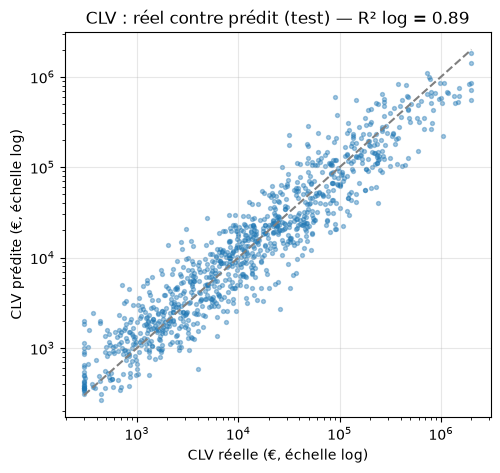

WindowsPath('C:/Users/Aelion/CISIA_UC/data/model_v2/metrics_clv.json')

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

clv_reelle = test["valeur_vie_client_eur"]
clv_predite = np.expm1(modele_clv.predict(X_test))
clv_baseline = np.full_like(clv_predite, np.expm1(y_clv_train.median()))
erreur_relative = (clv_predite - clv_reelle).abs() / clv_reelle

metriques_clv = {
    "modele_retenu": MODELE_CLV_RETENU,
    "mae_eur": mean_absolute_error(clv_reelle, clv_predite),
    "rmse_eur": mean_squared_error(clv_reelle, clv_predite) ** 0.5,
    "r2_eur": r2_score(clv_reelle, clv_predite),
    "r2_log": r2_score(np.log1p(clv_reelle), np.log1p(clv_predite)),
    "erreur_relative_mediane": float(erreur_relative.median()),
    "baseline_mae_eur": mean_absolute_error(clv_reelle, clv_baseline),
    "baseline_r2_eur": r2_score(clv_reelle, clv_baseline),
}
display(pd.Series(metriques_clv).to_frame("test").T)
par_taille = (pd.DataFrame({"taille": test["taille_entreprise"], "erreur_relative": erreur_relative, "clv": clv_reelle})
              .groupby("taille").agg(comptes=("clv", "size"), clv_mediane=("clv", "median"),
                                     erreur_relative_mediane=("erreur_relative", "median")))
display(par_taille.round(2))

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(clv_reelle, clv_predite, s=8, alpha=0.4)
bornes = [clv_reelle.min(), clv_reelle.max()]
ax.plot(bornes, bornes, "--", color="gray")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("CLV réelle (€, échelle log)")
ax.set_ylabel("CLV prédite (€, échelle log)")
ax.set_title(f"CLV : réel contre prédit (test) — R² log = {metriques_clv['r2_log']:.2f}")
sauver_figure(fig, "14_clv_reel_vs_predit")
plt.show()
write_manifest(MODEL_DIR / "metrics_clv.json", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in metriques_clv.items()})

**Lecture.** Le modèle explique l'essentiel de la variance en échelle logarithmique, et son
erreur en euros est bien inférieure à celle de la baseline. En euros, le R² et le RMSE restent
pénalisés par quelques comptes à plusieurs centaines de milliers d'euros. L'erreur relative
médiane donne l'ordre de grandeur utile au métier : la CLV estimée sert à **ordonner** les
comptes par enjeu, pas à prévoir un chiffre d'affaires au euro près.

### 12.3 Impact métier : combien de comptes et d'euros la priorisation peut-elle préserver ?

📘 **Explication — estimer l'impact, sans prétendre l'avoir mesuré**

Le modèle n'a pas été déployé : on ne peut pas **mesurer** des comptes sauvés. On peut en
revanche **estimer** l'intérêt de la liste produite sur le cycle simulé (les 1 000 comptes du
test), en comparant quatre façons de choisir les 150 comptes à appeler (D10) :

1. **le modèle** (priorité Haute : signalés au seuil D9, triés par perte attendue) ;
2. **au hasard** (espérance mathématique) ;
3. **les 150 plus gros revenus mensuels** (règle naïve « on protège les gros comptes ») ;
4. **la baseline métier D8** (les 150 scores de règle les plus élevés).

Pour chaque méthode : combien de comptes contactés allaient réellement partir, et quelle CLV
réelle ces comptes représentent (l'enjeu économique couvert).

On traduit ensuite en comptes sauvés avec un **taux de succès des relances** inconnu (hypothèse
**H05**, testée à 10, 20 et 30 %), diminué du coût des 150 relances (H01). Ces montants sont des
ordres de grandeur ; la mesure réelle passera par le groupe témoin de D12 (§13).

In [42]:
cycle_reel = cycle.merge(test[["client_id", "churn", "valeur_vie_client_eur", "revenu_mensuel_recurrent_eur"]], on="client_id")
cycle_reel["score_regle"] = score_regle_metier(X_test, X_train["nb_integrations"].median()).values
selections = {
    "Modèle (priorité Haute)": cycle_reel[cycle_reel["priorite"] == "Haute"],
    "150 plus gros MRR": cycle_reel.nlargest(CAPACITE_CSM_D10, "revenu_mensuel_recurrent_eur"),
    "Baseline métier D8": cycle_reel.nlargest(CAPACITE_CSM_D10, "score_regle"),
}
impact = []
for nom, sel in selections.items():
    impact.append({"méthode": nom, "comptes_contactés": len(sel), "churners_contactés": int(sel["churn"].sum()),
                   "clv_en_jeu_eur": float((sel["churn"] * sel["valeur_vie_client_eur"]).sum())})
impact.append({"méthode": "Au hasard (espérance)", "comptes_contactés": CAPACITE_CSM_D10,
               "churners_contactés": round(CAPACITE_CSM_D10 * cycle_reel["churn"].mean(), 1),
               "clv_en_jeu_eur": float(CAPACITE_CSM_D10 * (cycle_reel["churn"] * cycle_reel["valeur_vie_client_eur"]).mean())})
impact = pd.DataFrame(impact).set_index("méthode")
impact["précision"] = impact["churners_contactés"] / impact["comptes_contactés"]
display(impact.style.format({"clv_en_jeu_eur": "{:,.0f} €", "précision": "{:.0%}", "churners_contactés": "{:.0f}"}))

haute = selections["Modèle (priorité Haute)"]
sensibilite = pd.DataFrame([
    {"taux de succès H05": f"{tau:.0%}", "coût relance H01": f"{c} €",
     "comptes sauvés": haute["churn"].sum() * tau,
     "CLV préservée (€)": (haute["churn"] * haute["valeur_vie_client_eur"]).sum() * tau,
     "coût des 150 relances (€)": CAPACITE_CSM_D10 * c}
    for tau in (0.10, 0.20, 0.30) for c in COUTS_FP_EUR])
sensibilite["gain net estimé (€)"] = sensibilite["CLV préservée (€)"] - sensibilite["coût des 150 relances (€)"]
display(sensibilite.style.format({"comptes sauvés": "{:.1f}", "CLV préservée (€)": "{:,.0f}",
                                  "coût des 150 relances (€)": "{:,.0f}", "gain net estimé (€)": "{:,.0f}"}))

,comptes_contactés,churners_contactés,clv_en_jeu_eur,précision
méthode,,,,
Modèle (priorité Haute),150,97,"10,238,693 €",65%
150 plus gros MRR,150,32,"8,944,631 €",21%
Baseline métier D8,150,89,"4,749,124 €",59%
Au hasard (espérance),150,42,"1,831,396 €",28%


,taux de succès H05,coût relance H01,comptes sauvés,CLV préservée (€),coût des 150 relances (€),gain net estimé (€)
0,10%,50 €,9.7,"1,023,869","7,500","1,016,369"
1,10%,150 €,9.7,"1,023,869","22,500","1,001,369"
2,20%,50 €,19.4,"2,047,739","7,500","2,040,239"
3,20%,150 €,19.4,"2,047,739","22,500","2,025,239"
4,30%,50 €,29.1,"3,071,608","7,500","3,064,108"
5,30%,150 €,29.1,"3,071,608","22,500","3,049,108"


**Lecture.** Sur 150 appels, le modèle cible environ 2,3 fois plus de comptes qui allaient
réellement partir que le hasard, 3 fois plus que la règle des plus gros revenus, et davantage
que la baseline métier. Il couvre aussi la plus grande CLV en jeu : la règle des gros comptes
s'en approche en euros, mais en appelant surtout des clients qui ne comptaient pas partir, et
la baseline métier trouve des comptes à risque mais de faible valeur. Même avec l'hypothèse de succès la plus prudente (10 %) et le coût de
relance le plus élevé, le gain net estimé reste positif. **Limites** : ces chiffres portent sur
un cycle simulé de 1 000 comptes, avec un taux de succès supposé ; seul le protocole de groupe
témoin (D12–D13) permettra de mesurer l'impact réel.

### 12.4 Recette de la priorisation (D15)

📘 **Explication — le critère de recette D15**

D15 vérifie que la priorisation **ordonne** correctement les comptes par enjeu réel. On calcule,
pour chaque compte du test, une **perte réelle** = churn réel × CLV réelle (0 pour un compte resté
client), jamais transmise au modèle, puis trois contrôles :

- **(a)** exactitude arithmétique : perte attendue = score × CLV estimée, pour chaque compte ;
- **(b)** cohérence du classement : **corrélation de rang de Spearman** entre perte attendue et
  perte réelle. Spearman compare les *rangs* et non les valeurs : il répond à « les comptes
  classés en tête par le modèle sont-ils ceux qui représentent la plus grosse perte réelle ? ».
  Seuil D15 : ≥ 0,7 ;
- **(c)** contrôle individuel : aucun faux négatif (compte parti sans être signalé) ne doit se
  trouver parmi les plus grosses pertes réelles. D15 parle du « quartile supérieur du jeu de
  recette » ; sur un jeu où 72 % des pertes réelles valent 0, j'interprète ce quartile parmi les
  **pertes réelles non nulles**, sinon presque tous les comptes partis y figureraient.

In [43]:
from scipy.stats import spearmanr

cycle_reel["perte_reelle_eur"] = cycle_reel["churn"] * cycle_reel["valeur_vie_client_eur"]
ecart_arithmetique = (cycle_reel["score_churn"] * cycle_reel["valeur_vie_estimee_eur"] - cycle_reel["perte_attendue_eur"]).abs().max()
rho = spearmanr(cycle_reel["perte_attendue_eur"], cycle_reel["perte_reelle_eur"]).statistic
q3_pertes = cycle_reel.loc[cycle_reel["perte_reelle_eur"] > 0, "perte_reelle_eur"].quantile(0.75)
fn_critiques = cycle_reel[(cycle_reel["churn"] == 1) & (~cycle_reel["signale_D9"]) & (cycle_reel["perte_reelle_eur"] >= q3_pertes)]

# Le score est arrondi à 3 décimales et les montants à l'euro : l'écart toléré par l'arrondi
# vaut au plus 0,0005 x CLV estimée + 1 €. Tout écart supérieur signalerait une erreur de calcul.
ecarts = (cycle_reel["score_churn"] * cycle_reel["valeur_vie_estimee_eur"] - cycle_reel["perte_attendue_eur"]).abs()
borne_arrondi = 0.0005 * cycle_reel["valeur_vie_estimee_eur"] + 1
print(f"(a) écart maximal : {ecart_arithmetique:.1f} € ; comptes dont l'écart dépasse la borne d'arrondi : "
      f"{int((ecarts > borne_arrondi).sum())} -> {'respecté' if (ecarts <= borne_arrondi).all() else 'NON respecté'}")
print(f"(b) Spearman(perte attendue, perte réelle) = {rho:.3f} -> {'respecté' if rho >= 0.7 else 'NON respecté'} (seuil 0,7)")
print(f"(c) faux négatifs parmi le quartile supérieur des pertes réelles (≥ {q3_pertes:,.0f} €) : {len(fn_critiques)}")
if len(fn_critiques):
    display(fn_critiques[["client_id", "score_churn", "valeur_vie_estimee_eur", "valeur_vie_client_eur", "perte_reelle_eur"]]
            .sort_values("perte_reelle_eur", ascending=False).head(10))

# Diagnostics complémentaires pour comprendre le résultat de (b)
partis = cycle_reel["churn"] == 1
rho_partis = spearmanr(cycle_reel.loc[partis, "perte_attendue_eur"], cycle_reel.loc[partis, "perte_reelle_eur"]).statistic
rho_clv = spearmanr(cycle_reel["valeur_vie_estimee_eur"], cycle_reel["valeur_vie_client_eur"]).statistic
perte_totale = cycle_reel["perte_reelle_eur"].sum()
capture_haute = cycle_reel.loc[cycle_reel["priorite"] == "Haute", "perte_reelle_eur"].sum() / perte_totale
capture_oracle = cycle_reel["perte_reelle_eur"].nlargest(CAPACITE_CSM_D10).sum() / perte_totale
print("\nDiagnostics complémentaires :")
print(f"  part des pertes réelles nulles (comptes restés clients) : {(cycle_reel['perte_reelle_eur'] == 0).mean():.0%}")
print(f"  Spearman parmi les seuls comptes partis                 : {rho_partis:.3f}")
print(f"  Spearman CLV estimée / CLV réelle (tous les comptes)    : {rho_clv:.3f}")
print(f"  part de la perte réelle totale captée par les 150 Hautes : {capture_haute:.0%} "
      f"(maximum atteignable avec 150 comptes, en connaissant l'avenir : {capture_oracle:.0%})")

(a) écart maximal : 409.7 € ; comptes dont l'écart dépasse la borne d'arrondi : 0 -> respecté
(b) Spearman(perte attendue, perte réelle) = 0.290 -> NON respecté (seuil 0,7)
(c) faux négatifs parmi le quartile supérieur des pertes réelles (≥ 25,338 €) : 16


,client_id,score_churn,valeur_vie_estimee_eur,valeur_vie_client_eur,perte_reelle_eur
942,CLI-002532,0.147,123840.0,243614,243614
696,CLI-003757,0.258,83911.0,105998,105998
943,CLI-004440,0.280,75366.0,96301,96301
286,CLI-003672,0.025,66568.0,85505,85505
598,CLI-003224,0.072,43112.0,84035,84035
68,CLI-001685,0.238,147073.0,75655,75655
829,CLI-002104,0.167,25347.0,74860,74860
378,CLI-003122,0.253,48205.0,69216,69216
482,CLI-002568,0.115,49128.0,67749,67749
101,CLI-000671,0.226,25048.0,54402,54402



Diagnostics complémentaires :
  part des pertes réelles nulles (comptes restés clients) : 72%
  Spearman parmi les seuls comptes partis                 : 0.846
  Spearman CLV estimée / CLV réelle (tous les comptes)    : 0.944
  part de la perte réelle totale captée par les 150 Hautes : 84% (maximum atteignable avec 150 comptes, en connaissant l'avenir : 98%)


**Lecture — la recette D15 n'est pas entièrement satisfaite, et c'est une information utile.**

- **(a) respecté** : la perte attendue est exactement score × CLV ; le seul écart vient de
  l'arrondi du score affiché.
- **(b) non respecté tel que formulé** (Spearman = 0,29 contre 0,7 exigé). Le diagnostic montre
  pourquoi : 72 % des comptes ont une perte réelle nulle (ils sont restés), alors que leur perte
  *attendue* est positive, puisqu'une probabilité n'est jamais nulle. Sur une cible aussi
  dominée par des zéros, la corrélation de rang globale est mécaniquement faible, même pour un
  bon classement. Les autres indicateurs le confirment : parmi les comptes réellement partis,
  le classement par perte attendue suit bien la perte réelle (Spearman ≈ 0,85), la CLV estimée
  ordonne correctement les comptes (≈ 0,94), et les 150 priorités Hautes captent environ 84 %
  de la perte réelle totale, pour un maximum théorique de 98 %.
- **(c) non respecté** : 16 comptes partis, à forte perte réelle, n'ont pas été signalés parce
  que leur probabilité était sous le seuil D9. C'est le coût de la règle D14 déjà observé en
  §10.2 : un compte de très grande valeur mais de risque modéré n'entre jamais dans la liste.

**Ce que j'en conclus, sans modifier les critères après coup** : le critère (b) a été fixé comme
un ordre de grandeur de travail, pour un petit jeu de recette ; appliqué à un portefeuille
complet, il mesure surtout la proportion de zéros. Je propose au métier de le remplacer par la
**part de la perte réelle captée par la priorité Haute** (84 % ici), qui répond directement à
la question « les 150 appels portent-ils sur les plus grosses pertes ? ». Pour (c), je propose
un **filet de sécurité** : faire passer en priorité Moyenne les comptes sous le seuil dont la
perte attendue dépasse celle du 150ᵉ compte Haut. Ces deux évolutions touchent aux décisions
D14 et D15 : elles relèvent d'un arbitrage métier, pas d'un ajustement technique unilatéral.

### 12.5 Audit d'équité par segment

📘 **Explication — le modèle sert-il tous les segments de la même façon ?**

Pour chaque modalité de la taille d'entreprise, du secteur et du plan, on mesure au seuil D9 :

- le **rappel** : part des comptes qui partent effectivement détectés dans ce segment. Un rappel
  plus faible signifie que les clients de ce segment reçoivent moins souvent l'aide proposée ;
- la **précision** et la **part de comptes signalés**.

Les effectifs par segment sont petits (parfois moins de 30 comptes partis) : on calcule un
**intervalle de confiance de Wilson** à 95 % pour le rappel. Si les intervalles se recouvrent,
l'écart observé peut être dû au hasard ; on ne conclut pas à un biais sur un écart non
significatif, mais on le documente et on le surveille.

,segment,modalité,comptes,churners,rappel,IC95_bas,IC95_haut,précision,part_signalés
0,taille_entreprise,ETI,197,41,0.80,0.66,0.90,0.65,0.26
1,taille_entreprise,GE,81,17,1.00,0.82,1.00,0.71,0.30
2,taille_entreprise,PME,396,125,0.75,0.67,0.82,0.61,0.39
3,taille_entreprise,TPE,326,97,0.85,0.76,0.90,0.61,0.41
4,secteur,Commerce,162,50,0.72,0.58,0.83,0.60,0.37
5,secteur,Finance,170,43,0.74,0.60,0.85,0.68,0.28
6,secteur,Inconnu,54,15,0.87,0.62,0.96,0.68,0.35
7,secteur,Industrie,150,42,0.83,0.69,0.92,0.62,0.37
8,secteur,Public,59,18,0.78,0.55,0.91,0.78,0.31
9,secteur,Santé,123,29,0.93,0.78,0.98,0.57,0.38


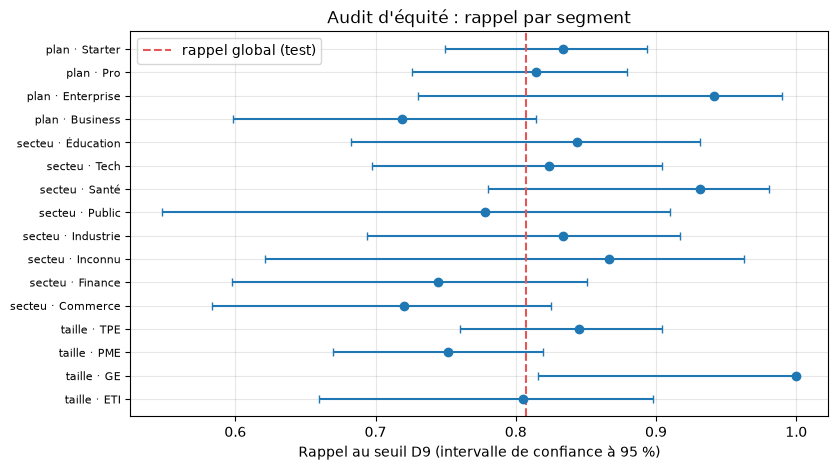

In [44]:
def intervalle_wilson(succes, n, z=1.96):
    """Intervalle de confiance à 95 % d'une proportion (méthode de Wilson, fiable sur petits effectifs)."""
    if n == 0:
        return (np.nan, np.nan)
    p = succes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    demi = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return (centre - demi, centre + demi)


audit = []
signale_test = pd.Series(proba_test >= SEUIL_D9, index=test.index)
for segment in ["taille_entreprise", "secteur", "plan"]:
    for modalite, idx in test.groupby(segment).groups.items():
        y_seg, s_seg = test.loc[idx, "churn"], signale_test.loc[idx]
        vp = int((y_seg & s_seg).sum())
        bas, haut = intervalle_wilson(vp, int(y_seg.sum()))
        audit.append({"segment": segment, "modalité": modalite, "comptes": len(idx), "churners": int(y_seg.sum()),
                      "rappel": vp / max(int(y_seg.sum()), 1), "IC95_bas": bas, "IC95_haut": haut,
                      "précision": vp / max(int(s_seg.sum()), 1), "part_signalés": s_seg.mean()})
audit = pd.DataFrame(audit)
display(audit.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
etiquettes = audit["segment"].str[:6] + " · " + audit["modalité"].astype(str)
ax.errorbar(audit["rappel"], range(len(audit)), xerr=[audit["rappel"] - audit["IC95_bas"], audit["IC95_haut"] - audit["rappel"]],
            fmt="o", capsize=3)
ax.axvline(metriques_test["rappel_seuil_D9"], color=COULEURS["churn"], linestyle="--", label="rappel global (test)")
ax.set_yticks(range(len(audit)), etiquettes, fontsize=8)
ax.set_xlabel("Rappel au seuil D9 (intervalle de confiance à 95 %)")
ax.set_title("Audit d'équité : rappel par segment")
ax.legend()
sauver_figure(fig, "15_audit_equite")
plt.show()

**Lecture.** Aucun segment n'est significativement moins bien servi : tous les intervalles de
confiance recouvrent le rappel global (≈ 81 %). Les rappels observés les plus faibles (plan
Business ≈ 72 %, secteurs Commerce ≈ 72 % et Finance ≈ 74 %, PME ≈ 75 %) restent compatibles avec
le hasard compte tenu des effectifs (15 à 125 comptes partis par segment). Je les documente
comme **points de surveillance** : si l'écart persiste sur plusieurs cycles, il faudra en
chercher la cause (signaux d'usage moins lisibles pour ces clients ?) plutôt que d'ajuster un
seuil par segment, ce qui introduirait un traitement différencié explicite.

## 13. Amélioration continue : ré-entraînement, suivi, versioning [C9]

Un modèle se dégrade avec le temps : les usages évoluent, l'offre change, la clientèle se
transforme. Cette section décrit comment détecter une dégradation, quand et comment
ré-entraîner, et comment tracer chaque version.

### 13.1 Détecter une dérive des données (PSI)

📘 **Explication — le Population Stability Index (PSI)**

Le PSI compare la distribution d'une variable entre une **référence** (les données
d'entraînement) et une **fenêtre courante** (le cycle du mois) :

1. on découpe la référence en 10 intervalles de même effectif (déciles) ;
2. on compte la part des comptes du cycle courant dans chaque intervalle ;
3. PSI = Σ (part courante − part de référence) × ln(part courante / part de référence).

Lecture usuelle : **< 0,10** stable, **0,10 à 0,25** à surveiller, **> 0,25** dérive importante
(seuil de l'alerte Prometheus du projet, `drift_alert_rules.yml`).

On calcule le PSI dans deux situations :

- **test contre train** : les deux viennent du même découpage aléatoire, donc le PSI doit être
  proche de zéro. C'est un contrôle de bon fonctionnement, pas une démonstration de détection ;
- **un lot volontairement dérivé**, qui simule un trimestre où l'engagement baisse (connexions
  plus anciennes de 30 jours, une intégration de moins, CSAT en baisse d'un point, 40 % d'usage
  en moins). Le dispositif doit alors déclencher l'alerte sur les variables concernées.

La fonction `drift_table` (module `src/drift.py`) est celle qu'utilise l'exporteur Prometheus
en production.

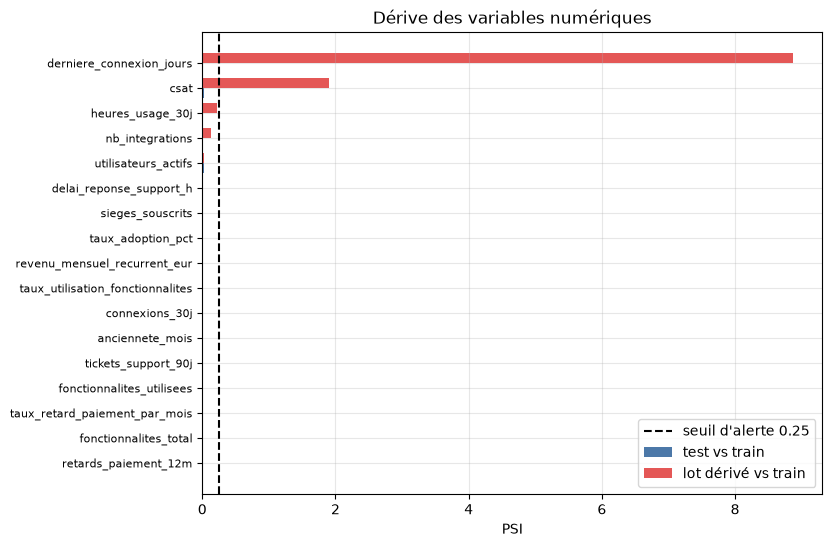

PSI maximal test vs train : 0.033 -> aucune alerte attendue
Variables en alerte sur le lot dérivé : ['derniere_connexion_jours', 'csat']
Part de comptes signalés : 36% sur le test, 75% sur le lot dérivé (dérive de la sortie du modèle)


In [45]:
from src.drift import drift_table

reference = train[NUMERIQUES_V2]
lot_derive = test[NUMERIQUES_V2].copy()
lot_derive["derniere_connexion_jours"] = lot_derive["derniere_connexion_jours"] + 30
lot_derive["nb_integrations"] = (lot_derive["nb_integrations"] - 1).clip(lower=0)
lot_derive["csat"] = (lot_derive["csat"] - 1).clip(lower=1)
lot_derive["heures_usage_30j"] = lot_derive["heures_usage_30j"] * 0.6

psi_test = drift_table(reference, test[NUMERIQUES_V2], NUMERIQUES_V2).set_index("feature")["psi"]
psi_derive = drift_table(reference, lot_derive, NUMERIQUES_V2).set_index("feature")["psi"]
tableau_psi = pd.DataFrame({"PSI test vs train": psi_test, "PSI lot dérivé vs train": psi_derive}).sort_values("PSI lot dérivé vs train")

fig, ax = plt.subplots(figsize=(8, 6))
positions = np.arange(len(tableau_psi))
ax.barh(positions - 0.2, tableau_psi["PSI test vs train"], height=0.4, label="test vs train", color=COULEURS["non_churn"])
ax.barh(positions + 0.2, tableau_psi["PSI lot dérivé vs train"], height=0.4, label="lot dérivé vs train", color=COULEURS["churn"])
ax.axvline(PSI_SEUIL_ALERTE, color="black", linestyle="--", label=f"seuil d'alerte {PSI_SEUIL_ALERTE}")
ax.set_yticks(positions, tableau_psi.index, fontsize=8)
ax.set_xlabel("PSI")
ax.set_title("Dérive des variables numériques")
ax.legend(loc="lower right")
sauver_figure(fig, "16_derive_psi")
plt.show()
print(f"PSI maximal test vs train : {psi_test.max():.3f} -> aucune alerte attendue")
print("Variables en alerte sur le lot dérivé :", list(psi_derive[psi_derive > PSI_SEUIL_ALERTE].index))

proba_derive = modele_churn.predict_proba(test[FEATURES_V2].assign(**lot_derive))[:, 1]
print(f"Part de comptes signalés : {np.mean(proba_test >= SEUIL_D9):.0%} sur le test, "
      f"{np.mean(proba_derive >= SEUIL_D9):.0%} sur le lot dérivé (dérive de la sortie du modèle)")

**Lecture.** Sans dérive, tous les PSI restent sous 0,05 : aucune fausse alerte. Sur le lot
simulé, **deux des quatre variables modifiées** (récence de connexion et CSAT) dépassent le seuil
et déclencheraient l'alerte `ChurnSaasDriftPSIEleve`. Les deux autres (usage réduit de 40 %,
une intégration de moins) restent sous 0,25 : **un PSI variable par variable peut laisser passer
une dérive modérée**. D'où l'intérêt d'un second indicateur, la **dérive de la sortie du
modèle** : la part de comptes signalés passe d'environ 36 % à 75 %. Un tel afflux dépasserait
largement la capacité CS et justifierait une analyse avant toute action. Un PSI élevé dit que **les données ont changé**, pas
que **le modèle se trompe** : la décision de ré-entraîner s'appuie aussi sur la performance
mesurée dès que les issues réelles sont connues.

### 13.2 Politique de ré-entraînement

| Déclencheur | Seuil | Action |
|---|---|---|
| Dérive des données | PSI > 0,25 sur une variable du top 5 d'importance | Analyse de la variable ; ré-entraînement si la performance baisse |
| Baisse de performance | Rappel < 75 % au seuil D9 sur un cycle dont les issues sont connues | Ré-entraînement prioritaire |
| Explosion du volume signalé | Signalés > 2 × la valeur habituelle | Vérification des données en amont (défaut d'export ?) avant tout |
| Calendrier | Tous les trimestres (aligné sur D13) | Ré-entraînement de routine sur les données fraîches |

**Procédure** (entièrement outillée dans le dépôt) :

1. nouvel export → `dvc add` des données brutes → `dvc repro` rejoue tout le pipeline ;
2. le nouvel entraînement est tracé dans **MLflow** (métriques, paramètres, `gold_sha256`) ;
3. **critères de promotion** du nouveau modèle : critère D8 respecté, rappel ≥ 80 % au seuil D9
   recalculé hors pli, PR-AUC au moins égale au modèle en service sur le même jeu de test,
   calibration vérifiée ;
4. mise en service : `MODEL_DIR` de l'API pointe vers le nouveau dossier ; **retour arrière** en
   une commande (`git checkout <commit précédent>` puis `dvc checkout`).

### 13.3 Traçabilité de cet entraînement dans MLflow

📘 **Explication — enregistrer le run dans MLflow**

MLflow garde l'historique des entraînements : paramètres, métriques et fichiers produits
(**artefacts**) de chaque run. On enregistre ici deux runs (churn et CLV) avec le tag
**`gold_sha256`**, l'empreinte du Gold v2 : à partir d'un run, on retrouve la version exacte des
données qui l'a produit.

- Si la variable d'environnement `MLFLOW_TRACKING_URI` pointe vers DagsHub, les runs y sont
  publiés (lien en page de garde) ; sinon, ils sont enregistrés localement dans
  `data/model_v2/mlflow.db`.
- Les expériences portent le même nom que celles de la v1 : dans l'interface MLflow, on compare
  directement les runs v1 et v2.
- L'appel est protégé (`try/except`) : un serveur MLflow indisponible ne doit pas empêcher le
  notebook de s'exécuter jusqu'au bout.

In [46]:
from src.tracking import flatten_metrics, log_training_run, resolve_tracking_uri

uri_mlflow = resolve_tracking_uri(MODEL_DIR)
etiquettes_communes = {"gold_version": "v2", "notebook": "notebook_certifiant_churn_saas", "commit_git": commit_git()}
try:
    run_churn = log_training_run(
        run_name=f"churn_v2_{MODELE_RETENU}", experiment_name="churn_saas_classification",
        params={"modele": MODELE_RETENU, "C": C_RETENU, "n_features": len(FEATURES_V2),
                "seuil_D9": round(float(SEUIL_D9), 4), "random_state": RANDOM_STATE},
        metrics=flatten_metrics({"test": metriques_test, "cv": {"pr_auc": grille.best_score_}}),
        tracking_uri=uri_mlflow, gold_sha256=sha_gold_v2, gold_dataset_path="data/gold/clients_churn_gold_v2.parquet",
        tags={**etiquettes_communes, "modele_retenu": MODELE_RETENU},
        artifacts=[MODEL_DIR / "model.joblib", MODEL_DIR / "model_manifest.json", MODEL_DIR / "scoring_manifest.json",
                   FIG_DIR / "09_courbes_roc_pr.png", FIG_DIR / "11_calibration.png", FIG_DIR / "13_explicabilite.png"],
        artifact_location=(MODEL_DIR / "mlartifacts").resolve().as_uri())
    run_clv = log_training_run(
        run_name=f"clv_v2_{MODELE_CLV_RETENU}", experiment_name="churn_saas_regression_clv",
        params={"modele": MODELE_CLV_RETENU, "cible": "log1p(valeur_vie_client_eur)", "n_features": len(FEATURES_V2)},
        metrics=flatten_metrics({k: v for k, v in metriques_clv.items() if k != "modele_retenu"}),
        tracking_uri=uri_mlflow, gold_sha256=sha_gold_v2, gold_dataset_path="data/gold/clients_churn_gold_v2.parquet",
        tags={**etiquettes_communes, "modele_retenu": MODELE_CLV_RETENU},
        artifacts=[MODEL_DIR / "model_clv.joblib", MODEL_DIR / "metrics_clv.json", FIG_DIR / "14_clv_reel_vs_predit.png"],
        artifact_location=(MODEL_DIR / "mlartifacts").resolve().as_uri())
    print("Serveur MLflow :", uri_mlflow if uri_mlflow.startswith("http") else "store local data/model_v2/mlflow.db")
    print("Run churn :", run_churn, "| Run CLV :", run_clv)
except Exception as erreur:
    print(f"MLflow indisponible ({type(erreur).__name__}) : runs non enregistrés, le reste du notebook n'est pas affecté.")

C:\Users\Aelion\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🏃 View run churn_v2_Régression logistique at: https://dagshub.com/guillaume.saidani/churn_saas.mlflow/#/experiments/0/runs/ecc7a46d54674eb29ca484c619853bd2
🧪 View experiment at: https://dagshub.com/guillaume.saidani/churn_saas.mlflow/#/experiments/0


🏃 View run clv_v2_Gradient boosting at: https://dagshub.com/guillaume.saidani/churn_saas.mlflow/#/experiments/1/runs/967ae94ebbfd4c13b6b79dd38b1e6616
🧪 View experiment at: https://dagshub.com/guillaume.saidani/churn_saas.mlflow/#/experiments/1


Serveur MLflow : https://dagshub.com/guillaume.saidani/churn_saas.mlflow
Run churn : ecc7a46d54674eb29ca484c619853bd2 | Run CLV : 967ae94ebbfd4c13b6b79dd38b1e6616


### 13.4 Suivi en production et mesure de l'impact réel

| Dispositif | Ce qu'il surveille | Outil |
|---|---|---|
| Dérive des entrées | PSI et test de Kolmogorov-Smirnov par variable, chaque cycle | Exporteur de dérive → Prometheus → alerte `ChurnSaasDriftPSIEleve` |
| Santé de l'API | Requêtes par code de statut, latence (95ᵉ centile), taille des lots | `/metrics` → Prometheus → tableau de bord Grafana |
| Performance réelle | Rappel et précision au seuil D9, dès que les issues du cycle sont connues | Rapport mensuel (à automatiser) |
| **Impact métier (D12–D13)** | Taux de résiliation des comptes traités contre un **groupe témoin** de 20 % des comptes priorisés, tirés au hasard et traités avec un mois de décalage (jamais privés d'action) | Consolidation trimestrielle |
| Qualité du code | Tests unitaires, récupération des données, build et santé de l'image | GitHub Actions à chaque push |

Le groupe témoin est la seule façon de distinguer un compte **sauvé par l'action** d'un compte
qui ne serait **de toute façon pas parti**. Le traitement différé (et non refusé) limite le
coût éthique de cette mesure.

### 13.5 Versioning : état actuel

| Objet | Outil | Où le consulter |
|---|---|---|
| Code, notebooks, manifestes, métriques | Git | GitHub (lien en page de garde) |
| Données brutes, Gold, modèles | DVC | DagsHub (lien en page de garde) ; `dvc pull` |
| Pipeline complet (dont ce notebook) | `dvc.yaml` / `dvc.lock` | `dvc repro` ne rejoue que ce qui a changé |
| Expériences | MLflow | DagsHub (lien en page de garde) |
| Environnement | `requirements*.txt`, `Dockerfile` | §15 |

## 14. Conclusion : synthèse et recommandations

📘 **Explication — tableau de bord final**

Cette cellule rassemble les chiffres clés produits dans le notebook, pour une lecture en un coup
d'œil. Tous proviennent des cellules précédentes : aucun chiffre n'est saisi à la main.

In [47]:
bilan = pd.Series({
    "Comptes (après dédoublonnage)": f"{len(gold_v2)}",
    "Taux de churn": f"{taux_churn:.1%}",
    "Features du modèle (Gold v2)": f"{len(FEATURES_V2)} (contre 30 en v1)",
    "Modèle churn retenu": f"{MODELE_RETENU} (C = {C_RETENU})",
    "PR-AUC validation croisée": f"{grille.best_score_:.3f}",
    "PR-AUC test / baseline métier D8": f"{metriques_test['pr_auc']:.3f} / {metriques_test['pr_auc_baseline_metier_D8']:.3f}",
    "ROC-AUC test": f"{metriques_test['roc_auc']:.3f}",
    "Critère D8 (gain ≥ 0,15)": f"{metriques_test['gain_pr_auc_vs_D8']:+.3f} -> {'respecté' if metriques_test['critere_D8_respecte'] else 'non respecté'}",
    "Seuil D9 (calculé hors pli)": f"{SEUIL_D9:.3f}",
    "Rappel / précision au seuil D9 (test)": f"{metriques_test['rappel_seuil_D9']:.1%} / {metriques_test['precision_seuil_D9']:.1%}",
    "Calibration (Brier test / référence)": f"{brier:.3f} / {brier_reference:.3f}",
    "Modèle CLV retenu": f"{MODELE_CLV_RETENU}",
    "CLV : R² log / erreur relative médiane": f"{metriques_clv['r2_log']:.3f} / {metriques_clv['erreur_relative_mediane']:.0%}",
    "Churners parmi les 150 priorités Hautes": f"{int(haute['churn'].sum())} (hasard : {CAPACITE_CSM_D10 * y_test.mean():.0f})",
    "Recette D15 : Spearman": f"{rho:.3f}",
}, name="valeur")
display(bilan.to_frame())

,valeur
Comptes (après dédoublonnage),5000
Taux de churn,28.0%
Features du modèle (Gold v2),20 (contre 30 en v1)
Modèle churn retenu,Régression logistique (C = 0.03)
PR-AUC validation croisée,0.792
PR-AUC test / baseline métier D8,0.761 / 0.593
ROC-AUC test,0.883
"Critère D8 (gain ≥ 0,15)",+0.168 -> respecté
Seuil D9 (calculé hors pli),0.286
Rappel / précision au seuil D9 (test),80.7% / 62.4%


### Synthèse

Le projet répond au besoin : il produit chaque mois une liste de comptes à contacter, ordonnée
par enjeu économique, avec un modèle **simple, explicable, calibré** et **nettement meilleur**
qu'une règle métier. La démarche est reproductible de bout en bout : données versionnées par
DVC, code sur GitHub, entraînements tracés dans MLflow, notebook rejoué par `dvc repro`,
intégration continue.

| Compétence | Ce que le notebook démontre |
|---|---|
| C1 | Cadrage du besoin (D1–D15), inventaire et gouvernance des données, alternatives |
| C2 | RGPD (base légale, finalité, minimisation, art. 22 testé), conséquences FP/FN, audit d'équité |
| C3 | Nettoyage démontré étape par étape, piège de fuite et leurres identifiés par des tests, Gold v2 versionné |
| C4 | Deux baselines, trois familles de modèles, ablation, règle de sélection fixée à l'avance |
| C5 | Réglage en validation croisée, seuil D9 hors pli, évaluation unique sur le test, calibration |
| C6 | Pipelines sérialisés, règle de décision figée, scoring d'un export brut, API testée de bout en bout |
| C7 | Architecture cible batch mensuel + CRM, contraintes mesurées, écarts identifiés |
| C8 | Métriques techniques et métier, impact estimé avec analyse de sensibilité, recette D15 |
| C9 | Détection de dérive (PSI et sortie du modèle), politique de ré-entraînement, MLflow, protocole de mesure d'impact |

### Recommandations

1. **Mettre le modèle v2 en service** : pointer `MODEL_DIR` de l'API et de l'image Docker vers
   `data/model_v2` ; la CI vérifiera le démarrage.
2. **Soumettre deux arbitrages au métier** : remplacer le critère D15(b) par la part de perte
   réelle captée par la priorité Haute ; ajouter un **filet de sécurité** pour les comptes de très
   grande valeur sous le seuil (§12.4).
3. **Confirmer auprès du propriétaire des données** que `derniere_connexion_jours` est calculée à
   la date du scoring, et réévaluer la capacité D10 à l'échelle du portefeuille complet (le cycle
   simulé ne contient que 1 000 comptes).
4. **Industrialiser le cycle mensuel** : planificateur du batch, connecteur CRM, routage des
   alertes Prometheus (Alertmanager), rapport mensuel de rappel sur les issues connues.
5. **Mesurer l'impact réel** avec le groupe témoin à traitement différé (D12), consolidé chaque
   trimestre (D13).
6. **Enrichir les données** : plusieurs instantanés mensuels (validation temporelle, tendances
   d'usage sur trois mois), qui sont la principale piste d'amélioration du modèle.

## 15. Annexes

### 15.1 Paramètres, versions et dépendances

📘 **Explication — tout ce qu'il faut pour reproduire**

On affiche les paramètres du notebook, les versions exactes des bibliothèques utilisées (lues
dans l'environnement d'exécution) et les fichiers de dépendances du projet. Avec le commit Git
et `dvc pull`, ces informations suffisent pour reproduire les résultats à l'identique.

In [48]:
from importlib.metadata import PackageNotFoundError, version

parametres = {
    "RANDOM_STATE": RANDOM_STATE, "RAPPEL_CIBLE_D9": RAPPEL_CIBLE_D9, "CAPACITE_CSM_D10": CAPACITE_CSM_D10,
    "GAIN_MIN_D8": GAIN_MIN_D8, "COUT_FN_EUR (F14)": COUT_FN_EUR, "COUTS_FP_EUR (H01)": COUTS_FP_EUR,
    "PSI_SEUIL_ALERTE": PSI_SEUIL_ALERTE, "C retenu": C_RETENU, "seuil D9": round(float(SEUIL_D9), 4),
    "validation croisée": "StratifiedKFold(5, shuffle=True, random_state=42)",
}
display(pd.Series(parametres, name="valeur").to_frame())

paquets = ["pandas", "numpy", "scikit-learn", "scipy", "matplotlib", "joblib", "pyarrow",
           "fastapi", "mlflow", "dvc", "nbconvert"]
versions = {}
for paquet in paquets:
    try:
        versions[paquet] = version(paquet)
    except PackageNotFoundError:
        versions[paquet] = "non installé"
display(pd.Series(versions, name="version").to_frame())
print("requirements.txt (image de l'API) :")
print((ROOT / "requirements.txt").read_text(encoding="utf-8"))

,valeur
RANDOM_STATE,42
RAPPEL_CIBLE_D9,0.8
CAPACITE_CSM_D10,150
GAIN_MIN_D8,0.15
COUT_FN_EUR (F14),6879
COUTS_FP_EUR (H01),"[50, 150]"
PSI_SEUIL_ALERTE,0.25
C retenu,0.03
seuil D9,0.2864
validation croisée,"StratifiedKFold(5, shuffle=True, random_state=42)"


,version
pandas,3.0.6
numpy,2.5.3
scikit-learn,1.9.1
scipy,1.18.1
matplotlib,3.11.2
joblib,1.6.0
pyarrow,25.0.1
fastapi,0.141.1
mlflow,3.16.1
dvc,3.67.1


requirements.txt (image de l'API) :
fastapi==0.141.1
uvicorn[standard]==0.53.0
pydantic==2.13.5
joblib==1.6.0
pandas==3.0.6
scikit-learn==1.9.1
scipy==1.18.1
prometheus_client==0.26.0
pyarrow==25.0.1



### 15.2 Fonctions utilitaires réutilisées (dossier `src/`)

📘 **Explication — inventaire du code réutilisable**

Le notebook ne duplique pas la logique : il appelle des fonctions du dossier `src/`, couvertes par
des tests unitaires (`tests/`). La cellule liste chaque fonction utilisée avec la première ligne
de sa documentation, lue directement dans le code.

In [49]:
import inspect

import src.drift
import src.features
import src.gold
import src.scoring
import src.silver
import src.tracking

fonctions = []
for module in [src.silver, src.features, src.gold, src.scoring, src.drift, src.tracking]:
    for nom, objet in inspect.getmembers(module, inspect.isfunction):
        if objet.__module__ == module.__name__ and not nom.startswith("_"):
            doc = (inspect.getdoc(objet) or "").split("\n")[0]
            fonctions.append({"module": module.__name__, "fonction": nom, "rôle": doc})
display(pd.DataFrame(fonctions))

,module,fonction,rôle
0,src.silver,build_silver_manifest,
1,src.silver,business_columns,
2,src.silver,clean_silver,Enchaîne NB02 §1-§6 dans l'ordre exact. Ne fai...
3,src.silver,drop_strict_duplicates,NB02 §1.
4,src.silver,normalize_secteur,NB02 §4. Sous-chaîne stable insensible à la ca...
5,src.silver,parse_date_multi,"NB02 §2. Essaie chaque format dans l'ordre, ne..."
6,src.silver,parse_numeric_fr,"NB02 §3. Nettoie virgule décimale, %, € et uni..."
7,src.features,completer_taux_adoption,`taux_adoption_pct` = 100 x utilisateurs_actif...
8,src.features,construire_features_v2,"Table Silver (sortie de `clean_silver`, avec o..."
9,src.gold,add_ratio_features,NB03 §4.


### 15.3 Vérifications finales

📘 **Explication — garde-fous exécutables**

Dernière cellule de code : une série d'**assertions**. Chacune vérifie une propriété
indispensable du livrable ; si l'une échoue, l'exécution du notebook s'arrête avec une erreur, au
lieu de produire des résultats faux en silence.

In [50]:
interdites = {"client_id", "sante_compte_fin_periode", "valeur_vie_client_eur", "churn", "commentaire_csm"}
verifications = {
    "aucune variable interdite dans les features": interdites.isdisjoint(FEATURES_V2),
    "aucun leurre dans les features": set(LEURRES).isdisjoint(FEATURES_V2),
    "train et test disjoints": set(train["client_id"]).isdisjoint(test["client_id"]),
    "seuil D9 calculé sans le test (hors pli)": manifeste_scoring["regle_decision"]["seuil_D9_calcule_sur"].startswith("prédictions hors pli"),
    "critère D8 respecté sur le test": metriques_test["critere_D8_respecte"],
    "actions conformes à D3 (art. 22)": all(action_est_conforme_d3(a) for a in ACTIONS_PAR_PRIORITE.values()),
    "artefacts présents": all((MODEL_DIR / f).exists() for f in ["model.joblib", "model_clv.joblib", "model_manifest.json",
                                                                 "scoring_manifest.json", "metrics.json", "metrics_clv.json",
                                                                 "scoring_exemple_cycle.parquet"]),
    "Gold v2 et manifeste présents": (GOLD_DIR / "clients_churn_gold_v2.parquet").exists() and (GOLD_DIR / "gold_v2_manifest.json").exists(),
}
display(pd.Series(verifications, name="vérifiée").to_frame())
assert all(verifications.values()), [k for k, v in verifications.items() if not v]
print(f"Toutes les vérifications passent. Figures produites : {len(list(FIG_DIR.glob('*.png')))} dans {FIG_DIR.relative_to(ROOT)}")

,vérifiée
aucune variable interdite dans les features,True
aucun leurre dans les features,True
train et test disjoints,True
seuil D9 calculé sans le test (hors pli),True
critère D8 respecté sur le test,True
actions conformes à D3 (art. 22),True
artefacts présents,True
Gold v2 et manifeste présents,True


Toutes les vérifications passent. Figures produites : 16 dans data\model_v2\figures


### 15.4 Reproduire ce notebook

```bash
git clone https://github.com/guillaumesaidani-coder/churn_saas.git && cd churn_saas
pip install -r requirements-dev.txt
dvc pull                                  # données brutes, Gold, modèles depuis DagsHub
dvc repro certification                   # exécute ce notebook ; version exécutée dans reports/notebooks/
```

### 15.5 Glossaire

| Terme | Définition |
|---|---|
| **Churn** | Résiliation d'un abonnement à l'échéance (D2) |
| **CLV** | Valeur vie client : revenu total attendu d'un compte sur sa durée de vie |
| **Fuite de données** | Variable contenant une information indisponible au moment de la prédiction ; elle gonfle artificiellement la performance |
| **Leurre** | Variable sans pouvoir prédictif, ajoutée pour tester la démarche |
| **Validation croisée** | Découpage répété du jeu d'entraînement pour estimer la performance et sa dispersion |
| **Hors pli** (*out-of-fold*) | Prédiction faite par un modèle qui n'a pas vu la ligne à l'entraînement |
| **ROC-AUC** | Probabilité qu'un compte qui part ait un score supérieur à un compte qui reste |
| **PR-AUC** | Aire sous la courbe précision-rappel ; plus informative que la ROC-AUC en classes déséquilibrées |
| **Rappel** | Part des comptes qui partent effectivement détectés |
| **Précision** | Part des comptes signalés qui partent effectivement |
| **Calibration / Brier** | Accord entre probabilités prédites et fréquences observées ; le score de Brier en est l'erreur quadratique |
| **Importance par permutation** | Baisse de performance quand on mélange une variable |
| **PSI** | Population Stability Index : mesure de dérive de la distribution d'une variable |
| **Pipeline** | Enchaînement figé préparation + modèle, identique à l'entraînement et en production |
| **DVC** | Outil de versioning des données et des modèles, complémentaire de Git |
| **MLflow** | Outil de suivi des expériences (paramètres, métriques, artefacts) |